### Load and Inspect CSVs

Load all provided CSV files into separate pandas DataFrames, display their column names, data types, and the first few rows to understand their structure.


In [ ]:
import pandas as pd

file_paths = [
    '/content/riyasewana_135to269.csv',
    '/content/riyasewana_1to134.csv',
    '/content/riyasewana_270to404.csv',
    '/content/riyasewana_405to530.csv'
]

dataframes = {}

for i, file_path in enumerate(file_paths):
    df_name = f'df_{i+1}'
    print(f"\n--- Loading and Inspecting {file_path} as {df_name} ---")
    try:
        df = pd.read_csv(file_path)
        dataframes[df_name] = df

        print(f"\nColumn names for {df_name}:")
        print(df.columns.tolist())

        print(f"\nData types for {df_name}:")
        df.info()

        print(f"\nFirst 5 rows for {df_name}:")
        print(df.head())
    except Exception as e:
        print(f"Error loading {file_path}: {e}")


--- Loading and Inspecting /content/riyasewana_135to269.csv as df_1 ---

Column names for df_1:
['URL', 'Title', 'Contact', 'Price', '< Back', 'Get Leasing', 'Make', 'Model', 'YOM', 'Mileage (km)', 'Gear', 'Fuel Type', 'Options', 'Engine (cc)', 'Details']

Data types for df_1:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4805 entries, 0 to 4804
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   URL           4805 non-null   object 
 1   Title         4801 non-null   object 
 2   Contact       4801 non-null   object 
 3   Price         4801 non-null   object 
 4   < Back        0 non-null      float64
 5   Get Leasing   4801 non-null   object 
 6   Make          4801 non-null   object 
 7   Model         4801 non-null   object 
 8   YOM           4801 non-null   float64
 9   Mileage (km)  4801 non-null   object 
 10  Gear          4801 non-null   object 
 11  Fuel Type     4801 non-null   object 
 12  Options

### Check Column Consistency and Duplicates

Compare column names across all DataFrames to ensure consistency and identify any duplicate column names within each individual file.


In [ ]:
import collections

# 1. Clean up column names for df_3 and df_4
for df_name, df in dataframes.items():
    if df_name in ['df_3', 'df_4']:
        df.columns = [col.strip() for col in df.columns]
        print(f"Cleaned column names for {df_name}:")
        print(df.columns.tolist())

# 2. Collect column names into a list of sets
all_columns_sets = [set(df.columns) for df in dataframes.values()]

# 3. Identify the union of all column names
union_columns = set().union(*all_columns_sets)
print(f"\nUnion of all column names: {list(union_columns)}")

# 4. Identify column names common to all DataFrames
common_columns = set.intersection(*all_columns_sets)
print(f"\nColumns common to all DataFrames: {list(common_columns)}")

# 5. Print the columns unique to each DataFrame
print("\nColumns unique to each DataFrame:")
for df_name, df in dataframes.items():
    unique_to_df = set(df.columns) - common_columns
    print(f"  {df_name}: {list(unique_to_df)}")

# 6. Check for duplicate column names within each DataFrame
print("\nChecking for duplicate column names within each DataFrame:")
for df_name, df in dataframes.items():
    duplicate_cols = [col for col, count in collections.Counter(df.columns).items() if count > 1]
    if duplicate_cols:
        print(f"  {df_name}: Duplicate columns found: {duplicate_cols}")
    else:
        print(f"  {df_name}: No duplicate columns found.")

Cleaned column names for df_3:
['URL', 'Title', 'Contact', 'Price', '< Back', 'Get Leasing', 'Make', 'Model', 'YOM', 'Mileage (km)', 'Gear', 'Fuel Type', 'Options', 'Engine (cc)', 'Details']
Cleaned column names for df_4:
['URL', 'Title', 'Contact', 'Price', '< Back', 'Get Leasing', 'Make', 'Model', 'YOM', 'Mileage (km)', 'Gear', 'Fuel Type', 'Options', 'Engine (cc)', 'Details']

Union of all column names: ['Title', 'Gear', 'Start Type', 'Price', 'Mileage (km)', 'Contact', 'Engine (cc)', '< Back', 'Model', 'Details', 'Make', 'URL', 'Fuel Type', 'YOM', 'Get Leasing', 'Options']

Columns common to all DataFrames: ['Model', 'Title', 'Details', 'Gear', '< Back', 'Make', 'Contact', 'URL', 'Price', 'YOM', 'Fuel Type', 'Mileage (km)', 'Get Leasing', 'Engine (cc)', 'Options']

Columns unique to each DataFrame:
  df_1: []
  df_2: ['Start Type']
  df_3: []
  df_4: []

Checking for duplicate column names within each DataFrame:
  df_1: No duplicate columns found.
  df_2: No duplicate columns found

### Check Data Type Consistency

Examine the data types of corresponding columns across all DataFrames to ensure they are consistent, which is crucial for a clean merge.


In [ ]:
column_data_types = {}

# Populate the dictionary with data types for each column across all DataFrames
for df_name, df in dataframes.items():
    for col in df.columns:
        if col not in column_data_types:
            column_data_types[col] = []
        column_data_types[col].append(df[col].dtype)

print("\n--- Checking Data Type Consistency ---")
# Check for consistency and print findings
for col, dtypes in column_data_types.items():
    unique_dtypes = list(set(dtypes))
    if len(unique_dtypes) > 1:
        print(f"Column '{col}' has INCONSISTENT data types: {unique_dtypes}")
    else:
        print(f"Column '{col}' has consistent data type: {unique_dtypes[0]}")


--- Checking Data Type Consistency ---
Column 'URL' has consistent data type: object
Column 'Title' has consistent data type: object
Column 'Contact' has consistent data type: object
Column 'Price' has consistent data type: object
Column '< Back' has INCONSISTENT data types: [dtype('float64'), dtype('O')]
Column 'Get Leasing' has consistent data type: object
Column 'Make' has consistent data type: object
Column 'Model' has consistent data type: object
Column 'YOM' has INCONSISTENT data types: [dtype('float64'), dtype('O')]
Column 'Mileage (km)' has consistent data type: object
Column 'Gear' has consistent data type: object
Column 'Fuel Type' has consistent data type: object
Column 'Options' has consistent data type: object
Column 'Engine (cc)' has consistent data type: object
Column 'Details' has consistent data type: object
Column 'Start Type' has consistent data type: object


### Merge DataFrames

Concatenate all DataFrames into a single, comprehensive DataFrame, addressing any identified inconsistencies if necessary to avoid data issues.


Converting the 'YOM' and '< Back' columns in all DataFrames to string type, then concatenate all individual DataFrames into a single DataFrame and display its head, column names, and info to verify the merge and data types.



In [ ]:
import numpy as np

# Convert inconsistent columns to object type in all DataFrames
columns_to_convert = ['YOM', '< Back']
for df_name, df in dataframes.items():
    for col in columns_to_convert:
        if col in df.columns:
            # Convert non-numeric values to NaN first to handle mixed types gracefully
            if col == 'YOM':
                # Attempt to convert to numeric, coerce errors to NaN, then fill NaN and convert to string
                df[col] = pd.to_numeric(df[col], errors='coerce').fillna('').astype(str)
            elif col == '< Back':
                # For '< Back', convert to string, replacing NaN with an empty string or similar if desired
                df[col] = df[col].astype(str).replace('nan', '')
        else:
            print(f"Warning: Column '{col}' not found in {df_name}, skipping conversion.")

# Concatenate all DataFrames into a single DataFrame
merged_df = pd.concat(dataframes.values(), ignore_index=True)

print("\n--- Merged DataFrame Overview ---")
print("\nFirst 5 rows of merged_df:")
print(merged_df.head())

print("\nColumn names of merged_df:")
print(merged_df.columns.tolist())

print("\nData types of merged_df:")
merged_df.info()


--- Merged DataFrame Overview ---

First 5 rows of merged_df:
                                                 URL  \
0  https://riyasewana.com/buy/toyota-premio-g-sal...   
1  https://riyasewana.com/buy/chevrolet-beat-lt-s...   
2  https://riyasewana.com/buy/mitsubishi-ek-wagon...   
3  https://riyasewana.com/buy/suzuki-swift-rs-sal...   
4  https://riyasewana.com/buy/toyota-soluna-sale-...   

                                               Title       Contact  \
0           Toyota Premio G Superior 2018 Car (Used)  071 428 0268   
1                  Chevrolet Beat LT 2012 Car (Used)  070 778 7785   
2  Mitsubishi EK Wagon G PILOT 2023 Car Unregiste...  077 726 1612   
3              Suzuki Swift RS Turbo 2017 Car (Used)  077 238 9751   
4                      Toyota Soluna 2000 Car (Used)  077 921 9537   

                          Price < Back  \
0                Rs. 15,500,000          
1  Rs. 3,950,000(Ongoing Lease)          
2                 Rs. 7,390,000          
3          

### Save Merged Data


In [ ]:
output_file_path = 'riyasewana_merged.csv'
merged_df.to_csv(output_file_path, index=False)

print(f"Merged DataFrame successfully saved to {output_file_path}")

Merged DataFrame successfully saved to riyasewana_merged.csv


### Load Merged CSV to Cleaning, EDA and Feature Engineering

In [ ]:
import pandas as pd

merged_df = pd.read_csv('/content/riyasewana_merged.csv')

print("Successfully loaded 'riyasewana_merged.csv' into merged_df.")
print(merged_df.head())

Successfully loaded 'riyasewana_merged.csv' into merged_df.
                                                 URL  \
0  https://riyasewana.com/buy/toyota-premio-g-sal...   
1  https://riyasewana.com/buy/chevrolet-beat-lt-s...   
2  https://riyasewana.com/buy/mitsubishi-ek-wagon...   
3  https://riyasewana.com/buy/suzuki-swift-rs-sal...   
4  https://riyasewana.com/buy/toyota-soluna-sale-...   

                                               Title       Contact  \
0           Toyota Premio G Superior 2018 Car (Used)  071 428 0268   
1                  Chevrolet Beat LT 2012 Car (Used)  070 778 7785   
2  Mitsubishi EK Wagon G PILOT 2023 Car Unregiste...  077 726 1612   
3              Suzuki Swift RS Turbo 2017 Car (Used)  077 238 9751   
4                      Toyota Soluna 2000 Car (Used)  077 921 9537   

                          Price < Back  \
0                Rs. 15,500,000    NaN   
1  Rs. 3,950,000(Ongoing Lease)    NaN   
2                 Rs. 7,390,000    NaN   
3             

### Inspect Merged DataFrame


In [ ]:
print("\n--- Merged DataFrame Structure and Content ---")

print("\nColumn names of merged_df:")
print(merged_df.columns.tolist())

print("\nData types of merged_df:")
merged_df.info()

print("\nFirst 5 rows of merged_df:")
print(merged_df.head())


--- Merged DataFrame Structure and Content ---

Column names of merged_df:
['URL', 'Title', 'Contact', 'Price', '< Back', 'Get Leasing', 'Make', 'Model', 'YOM', 'Mileage (km)', 'Gear', 'Fuel Type', 'Options', 'Engine (cc)', 'Details', 'Start Type']

Data types of merged_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19865 entries, 0 to 19864
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   URL           19865 non-null  object 
 1   Title         19838 non-null  object 
 2   Contact       19837 non-null  object 
 3   Price         19837 non-null  object 
 4   < Back        9182 non-null   object 
 5   Get Leasing   19835 non-null  object 
 6   Make          19837 non-null  object 
 7   Model         19837 non-null  object 
 8   YOM           19835 non-null  float64
 9   Mileage (km)  19837 non-null  object 
 10  Gear          19830 non-null  object 
 11  Fuel Type     19830 non-null  object 
 12  Options 

### Generate Descriptive Statistics

Calculate and display descriptive statistics for numerical columns in the merged DataFrame to get an overview of the data.


In [ ]:
print("\n--- Descriptive Statistics for Numerical Columns ---")

# Identify numerical columns, focusing on 'YOM' as it's the only one identified as numerical after the merge
numerical_cols = merged_df.select_dtypes(include=['number']).columns.tolist()

# If 'YOM' is not in numerical_cols (e.g., if it was converted to object during merge and re-read as object)
# ensure it's handled if it contains numeric-like data, or explicitly cast if needed.
# Based on the last merged_df.info(), YOM was float64 again after reloading, so this should work.

if 'YOM' not in numerical_cols:
    print("Warning: 'YOM' not identified as a numerical column by select_dtypes. Checking current dtype:")
    print(f"'YOM' dtype: {merged_df['YOM'].dtype}")
    # Attempt to convert to numeric if it's currently object but should be numeric
    if merged_df['YOM'].dtype == 'object':
        try:
            merged_df['YOM'] = pd.to_numeric(merged_df['YOM'], errors='coerce')
            print("Converted 'YOM' to numeric type for descriptive statistics.")
            numerical_cols = merged_df.select_dtypes(include=['number']).columns.tolist()
        except Exception as e:
            print(f"Could not convert 'YOM' to numeric: {e}")

if numerical_cols:
    print(f"Numerical columns identified: {numerical_cols}")
    print(merged_df[numerical_cols].describe())
else:
    print("No numerical columns found to describe.")


--- Descriptive Statistics for Numerical Columns ---
Numerical columns identified: ['YOM']
                YOM
count  19835.000000
mean    2006.597025
std       76.500780
min        0.000000
25%     2003.000000
50%     2012.000000
75%     2017.000000
max     2550.000000


### Visualize Column Distributions

Generate histograms for numerical columns and bar charts for categorical columns to visualize their distributions, including legends.


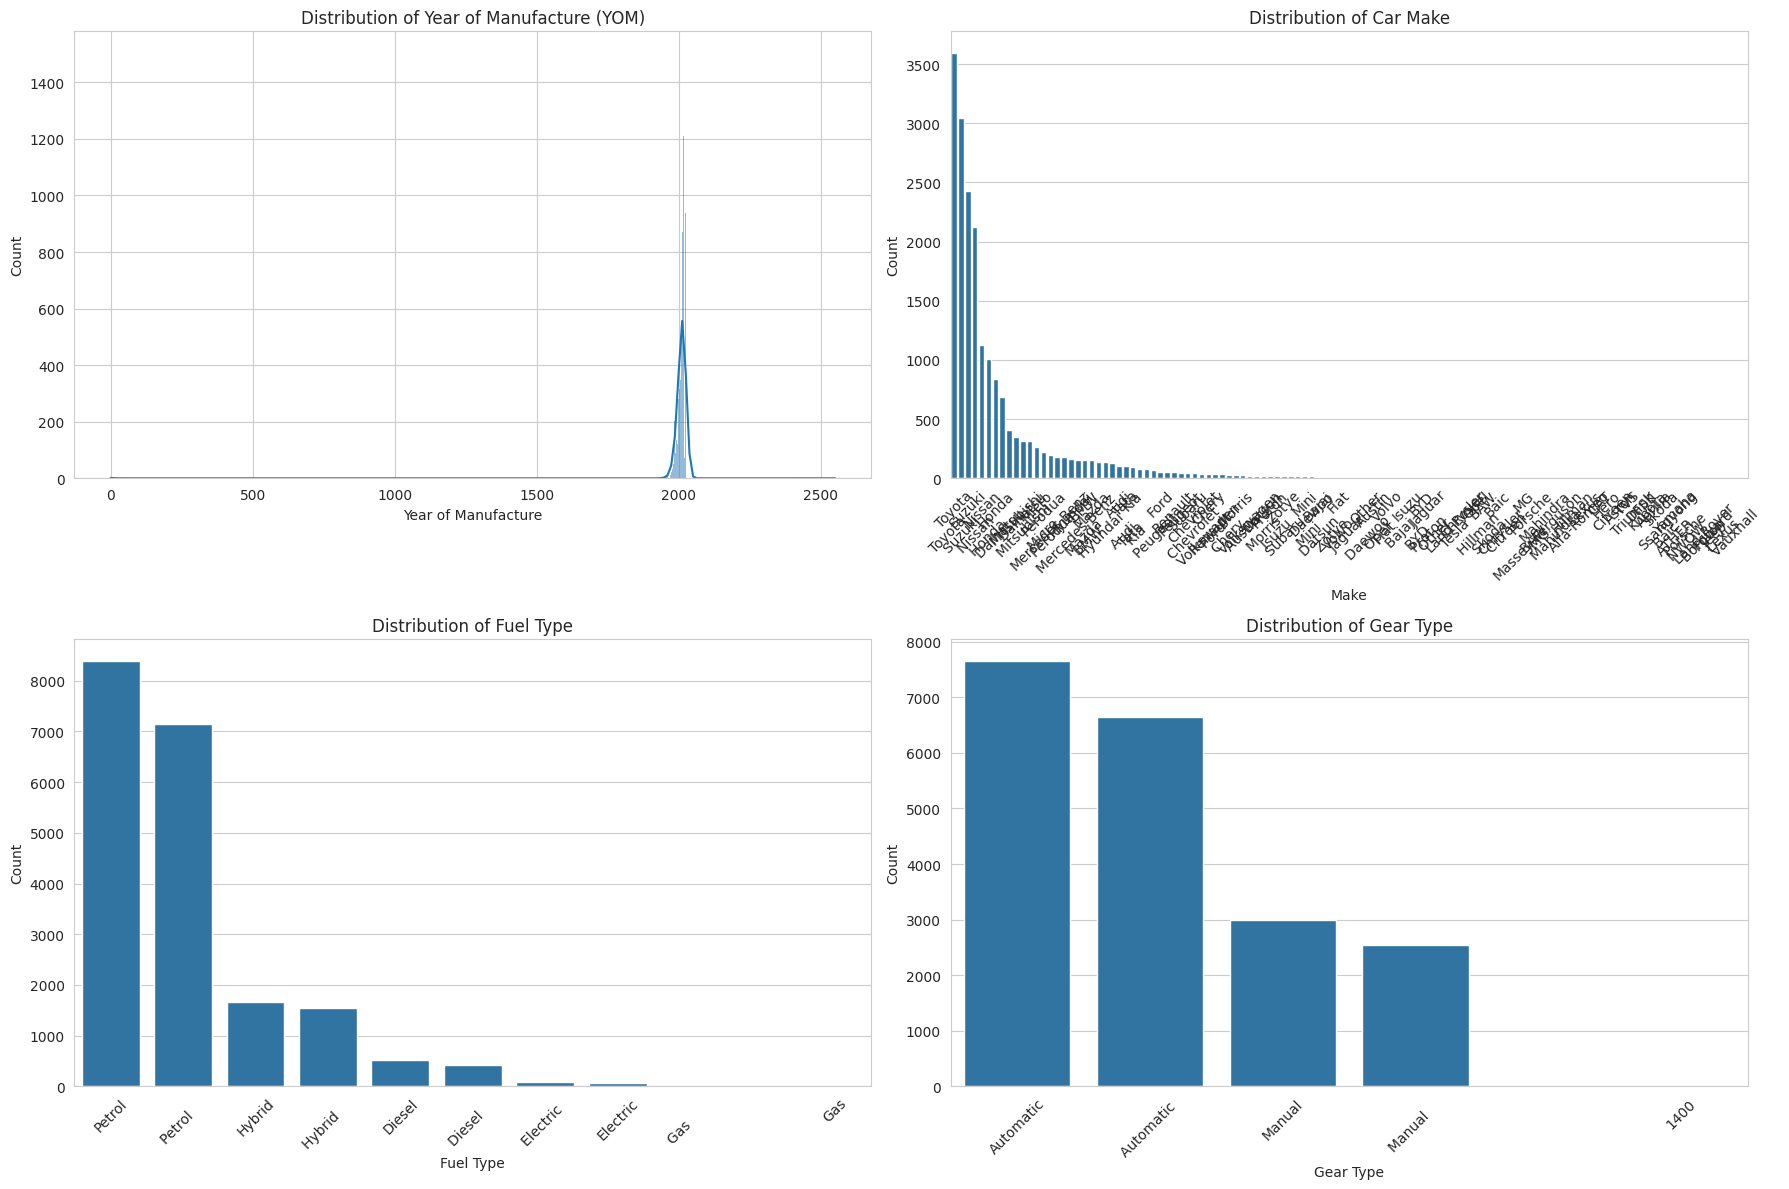

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for better aesthetics
sns.set_style("whitegrid")

# Create a figure and a set of subplots
# Adjust figsize based on the number of plots (1 histogram + 3 bar charts)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# --- 1. Histogram for 'YOM' (Numerical Column) ---
sns.histplot(data=merged_df, x='YOM', kde=True, ax=axes[0])
axes[0].set_title('Distribution of Year of Manufacture (YOM)')
axes[0].set_xlabel('Year of Manufacture')
axes[0].set_ylabel('Count')

# --- 2. Bar Chart for 'Make' (Categorical Column) ---
sns.countplot(data=merged_df, x='Make', order=merged_df['Make'].value_counts().index, ax=axes[1])
axes[1].set_title('Distribution of Car Make')
axes[1].set_xlabel('Make')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45) # Rotate x-axis labels

# --- 3. Bar Chart for 'Fuel Type' (Categorical Column) ---
sns.countplot(data=merged_df, x='Fuel Type', order=merged_df['Fuel Type'].value_counts().index, ax=axes[2])
axes[2].set_title('Distribution of Fuel Type')
axes[2].set_xlabel('Fuel Type')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45) # Rotate x-axis labels

# --- 4. Bar Chart for 'Gear' (Categorical Column) ---
sns.countplot(data=merged_df, x='Gear', order=merged_df['Gear'].value_counts().index, ax=axes[3])
axes[3].set_title('Distribution of Gear Type')
axes[3].set_xlabel('Gear Type')
axes[3].set_ylabel('Count')
axes[3].tick_params(axis='x', rotation=45) # Rotate x-axis labels

plt.tight_layout()
plt.show()

### Visualize Outliers

Generate box plots for relevant numerical columns to visually identify potential outliers, including legends.


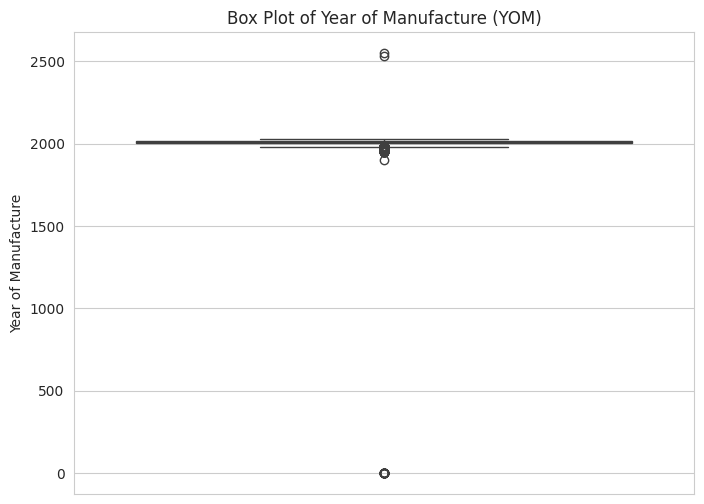

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for better aesthetics
sns.set_style("whitegrid")

# Create a figure and an axes object
plt.figure(figsize=(8, 6))
ax = sns.boxplot(y=merged_df['YOM'])

# Set title and labels
ax.set_title('Box Plot of Year of Manufacture (YOM)')
ax.set_ylabel('Year of Manufacture')

# Display the plot
plt.show()

In [ ]:
rows = df[df["Gear"] == 1400]


print("Number of rows found:", len(rows))

rows.T   # Transpose for easy viewing


Number of rows found: 0


""
URL
Title
Contact
Price
< Back
Get Leasing
Make
Model
YOM
Mileage (km)


### Data Analysis Key Findings

*   The dataset, `riyasewana_merged.csv`, was successfully loaded and contains 19,865 entries across 16 columns, including `URL`, `Title`, `Price`, `Make`, `Model`, `YOM`, `Mileage (km)`, `Gear`, `Fuel Type`, and `Engine (cc)`.
*   Initial data type inspection revealed that most columns are of `object` type, with `YOM` (Year of Manufacture) being the only numerical column initially identified as `float64`.
*   Several columns exhibit missing values, with `Title` having 19,838 non-null entries, `Contact` having 19,837, and `YOM` having 19,835 out of 19,865 total entries. Columns like `< Back` (9,182 non-null) and `Start Type` (7 non-null) are largely empty.
*   Descriptive statistics for the `YOM` column show a mean of 2006.6, a standard deviation of 76.5, and a broad range from a minimum of 0 to a maximum of 2550. These extreme values suggest the presence of significant data quality issues or outliers.
*   Distributions of key features were visualized: a histogram for `YOM` and bar charts for categorical columns like `Make`, `Fuel Type`, and `Gear` were generated.
*   A box plot for `YOM` visually confirmed the presence of outliers, consistent with the descriptive statistics showing years like 0 and 2550.


### URL

In [ ]:
if 'URL' in merged_df.columns:
    merged_df = merged_df.drop(columns=['URL'])
    print("Column 'URL' successfully deleted.")
else:
    print("Column 'URL' not found in the DataFrame.")

print("\nUpdated DataFrame head after 'URL' column deletion:")
print(merged_df.head())

print("\nUpdated DataFrame info:")
merged_df.info()

Column 'URL' not found in the DataFrame.

Updated DataFrame head after 'URL' column deletion:
                                               Title       Contact  \
0           Toyota Premio G Superior 2018 Car (Used)  071 428 0268   
1                  Chevrolet Beat LT 2012 Car (Used)  070 778 7785   
2  Mitsubishi EK Wagon G PILOT 2023 Car Unregiste...  077 726 1612   
3              Suzuki Swift RS Turbo 2017 Car (Used)  077 238 9751   
4                      Toyota Soluna 2000 Car (Used)  077 921 9537   

                          Price < Back  \
0                Rs. 15,500,000    NaN   
1  Rs. 3,950,000(Ongoing Lease)    NaN   
2                 Rs. 7,390,000    NaN   
3                    Negotiable    NaN   
4                 Rs. 3,290,000    NaN   

                                         Get Leasing        Make  \
0  Central Finance වෙතින් මාසික වාරිකය රු.1885 සි...      Toyota   
1  Central Finance වෙතින් මාසික වාරිකය රු.1885 සි...   Chevrolet   
2  Central Finance වෙතින් මා

### Clean '< Back' Column

Inspect the unique non-null values and null value count of the '< Back' column and then remove it from the DataFrame due to its lack of analytical value.

The '< Back' column has a significant number of null values and does not appear to contain meaningful analytical information.

In [ ]:
print("\n--- Null value count in '< Back>' ---")
print(merged_df['< Back'].isnull().sum())

print("\n--- Non-null unique values in '< Back>' ---")
print(merged_df['< Back'].dropna().unique())

if '< Back' in merged_df.columns:
    merged_df = merged_df.drop(columns=['< Back'])
    print("\nColumn '< Back>' successfully deleted.")
else:
    print("\nColumn '< Back>' not found in the DataFrame.")

print("\nUpdated DataFrame info after '< Back>' column deletion:")
merged_df.info()


--- Null value count in '< Back>' ---
10683

--- Non-null unique values in '< Back>' ---
['       ']

Column '< Back>' successfully deleted.

Updated DataFrame info after '< Back>' column deletion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19865 entries, 0 to 19864
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         19838 non-null  object 
 1   Contact       19837 non-null  object 
 2   Price         19837 non-null  object 
 3   Get Leasing   19835 non-null  object 
 4   Make          19837 non-null  object 
 5   Model         19837 non-null  object 
 6   YOM           19835 non-null  float64
 7   Mileage (km)  19837 non-null  object 
 8   Gear          19830 non-null  object 
 9   Fuel Type     19830 non-null  object 
 10  Options       19830 non-null  object 
 11  Engine (cc)   19837 non-null  object 
 12  Details       19835 non-null  object 
dtypes: float64(1), object(12)
memory usage: 2.

### Start Type

Inspect the non-null values of the 'Start Type' column and then remove it from the DataFrame.

In [ ]:
print("\n--- Non-null unique values in 'Start Type' ---")
print(merged_df['Start Type'].dropna().unique())

if 'Start Type' in merged_df.columns:
    merged_df = merged_df.drop(columns=['Start Type'])
    print("\nColumn 'Start Type' successfully deleted.")
else:
    print("\nColumn 'Start Type' not found in the DataFrame.")

print("\nUpdated DataFrame info after 'Start Type' column deletion:")
merged_df.info()


--- Non-null unique values in 'Start Type' ---
['Kick' 'Kick / Electric']

Column 'Start Type' successfully deleted.

Updated DataFrame info after 'Start Type' column deletion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19865 entries, 0 to 19864
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         19838 non-null  object 
 1   Contact       19837 non-null  object 
 2   Price         19837 non-null  object 
 3   < Back        9182 non-null   object 
 4   Get Leasing   19835 non-null  object 
 5   Make          19837 non-null  object 
 6   Model         19837 non-null  object 
 7   YOM           19835 non-null  float64
 8   Mileage (km)  19837 non-null  object 
 9   Gear          19830 non-null  object 
 10  Fuel Type     19830 non-null  object 
 11  Options       19830 non-null  object 
 12  Engine (cc)   19837 non-null  object 
 13  Details       19835 non-null  object 
dtypes: float64(1), objec

### Get Leasing

Remove the 'Get Leasing' column.

In [ ]:
if 'Get Leasing' in merged_df.columns:
    merged_df = merged_df.drop(columns=['Get Leasing'])
    print("Column 'Get Leasing' successfully deleted.")
else:
    print("Column 'Get Leasing' not found in the DataFrame.")

print("\nUpdated DataFrame info after 'Get Leasing' column deletion:")
merged_df.info()

Column 'Get Leasing' successfully deleted.

Updated DataFrame info after 'Get Leasing' column deletion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19865 entries, 0 to 19864
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         19838 non-null  object 
 1   Contact       19837 non-null  object 
 2   Price         19837 non-null  object 
 3   Make          19837 non-null  object 
 4   Model         19837 non-null  object 
 5   YOM           19835 non-null  float64
 6   Mileage (km)  19837 non-null  object 
 7   Gear          19830 non-null  object 
 8   Fuel Type     19830 non-null  object 
 9   Options       19830 non-null  object 
 10  Engine (cc)   19837 non-null  object 
 11  Details       19835 non-null  object 
dtypes: float64(1), object(11)
memory usage: 1.8+ MB


### Contact

Remove the 'Contact' column.

In [ ]:
if 'Contact' in merged_df.columns:
    merged_df = merged_df.drop(columns=['Contact'])
    print("Column 'Contact' successfully deleted.")
else:
    print("Column 'Contact' not found in the DataFrame.")

print("\nUpdated DataFrame info after 'Contact' column deletion:")
merged_df.info()

Column 'Contact' successfully deleted.

Updated DataFrame info after 'Contact' column deletion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19865 entries, 0 to 19864
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         19838 non-null  object 
 1   Price         19837 non-null  object 
 2   Make          19837 non-null  object 
 3   Model         19837 non-null  object 
 4   YOM           19835 non-null  float64
 5   Mileage (km)  19837 non-null  object 
 6   Gear          19830 non-null  object 
 7   Fuel Type     19830 non-null  object 
 8   Options       19830 non-null  object 
 9   Engine (cc)   19837 non-null  object 
 10  Details       19835 non-null  object 
dtypes: float64(1), object(10)
memory usage: 1.7+ MB


In [ ]:
merged_df.head()

,Title,Price,Make,Model,YOM,Mileage (km),Gear,Fuel Type,Options,Engine (cc),Details
0,Toyota Premio G Superior 2018 Car (Used),"Rs. 15,500,000",Toyota,Premio G Superior,2018.0,136500,Automatic,Petrol,"AIR CONDITION, POWER STEERING, POWER MIRROR, P...",1500,"First owner, personally used vehicle, Company ..."
1,Chevrolet Beat LT 2012 Car (Used),"Rs. 3,950,000(Ongoing Lease)",Chevrolet,Beat LT,2012.0,107000,Manual,Petrol,"AIR CONDITION, POWER STEERING, POWER MIRROR, P...",1200,කරුණාකර හොදින් කියවා WhatsApp පණිවුඩ මගින් විස...
2,Mitsubishi EK Wagon G PILOT 2023 Car Unregiste...,"Rs. 7,390,000",Mitsubishi,EK Wagon G PILOT,2023.0,15000,Automatic,Petrol,"AIR CONDITION, POWER STEERING, POWER MIRROR, P...",660,MITSUBISHI EK Wagon G GradePush Start/ AUTO Pi...
3,Suzuki Swift RS Turbo 2017 Car (Used),Negotiable,Suzuki,Swift RS Turbo,2017.0,106500,Automatic,Petrol,"AIR CONDITION, POWER STEERING, POWER MIRROR, P...",1000,1st owner100% accident freeExcellent body cond...
4,Toyota Soluna 2000 Car (Used),"Rs. 3,290,000",Toyota,Soluna,2000.0,149003,Manual,Petrol,"AIR CONDITION, POWER STEERING",1500,🔶️Toyota Soluna🔶️2000 Brandnew🔶️1500cc 5fwd🔶️A...


### Make

In [ ]:
print("\n--- Unique Makes in the DataFrame ---")
print(merged_df['Make'].unique())


--- Unique Makes in the DataFrame ---
['Toyota' 'Chevrolet' 'Mitsubishi' 'Suzuki' 'Nissan' 'BMW' 'Honda'
 'Daihatsu' 'Perodua' 'Mercedes-Benz' 'Jaguar' 'Hyundai' 'Tata' 'Chery'
 'Micro' 'Fiat' 'Morris' 'Kia' 'Proton' 'Datsun' 'Ford' 'Audi' 'Mazda'
 'Peugeot' 'Austin' 'Land-Rover' 'Renault' 'Daewoo' 'MG' 'BYD' 'Subaru'
 'Volkswagen' 'Opel' 'Mini' 'Chrysler' 'Citroen' 'Isuzu' 'Bajaj' 'Zotye'
 'Aston' nan 'Porsche' 'Other' 'Volvo' 'BAW' 'Triumph' 'Mahindra'
 'Massey-Ferguson' 'Alfa-Romeo' 'Hillman' 'CAT' 'DFSK' 'Baic' 'Ssangyong'
 'Skoda' 'Aprilia' 'Lexus' 'Daihatsu      ' 'Chevrolet     '
 'Toyota        ' 'BMW           ' 'Nissan        ' 'Honda         '
 'Suzuki        ' 'Mitsubishi    ' 'Mercedes-Benz ' 'Perodua       '
 'Hyundai       ' 'Micro         ' 'Chery         ' 'Daewoo        '
 'Audi          ' 'Mazda         ' 'Zotye         ' 'Fiat          '
 'Tata          ' 'Mini          ' 'Renault       ' 'Ford          '
 'Volkswagen    ' 'Kia           ' 'Peugeot       ' 'Volvo  

In [ ]:
# Strip whitespace from Make column
merged_df["Make"] = merged_df["Make"].astype(str).str.strip()

# Replace empty strings and "nan" text with real NaN
merged_df["Make"] = merged_df["Make"].replace(["", "nan", "None"], np.nan)

# Drop rows where Make is missing
merged_df = merged_df.dropna(subset=["Make"])

In [ ]:
print("\n--- Unique Makes in the DataFrame ---")
print(merged_df['Make'].unique())


--- Unique Makes in the DataFrame ---
['Toyota' 'Chevrolet' 'Mitsubishi' 'Suzuki' 'Nissan' 'BMW' 'Honda'
 'Daihatsu' 'Perodua' 'Mercedes-Benz' 'Jaguar' 'Hyundai' 'Tata' 'Chery'
 'Micro' 'Fiat' 'Morris' 'Kia' 'Proton' 'Datsun' 'Ford' 'Audi' 'Mazda'
 'Peugeot' 'Austin' 'Land-Rover' 'Renault' 'Daewoo' 'MG' 'BYD' 'Subaru'
 'Volkswagen' 'Opel' 'Mini' 'Chrysler' 'Citroen' 'Isuzu' 'Bajaj' 'Zotye'
 'Aston' 'Porsche' 'Other' 'Volvo' 'BAW' 'Triumph' 'Mahindra'
 'Massey-Ferguson' 'Alfa-Romeo' 'Hillman' 'CAT' 'DFSK' 'Baic' 'Ssangyong'
 'Skoda' 'Aprilia' 'Lexus' 'ATHER' 'NWOW' 'Borgward' 'Tesla' 'Foton'
 'Jeep' 'Vauxhall']


In [ ]:
print("Missing Make values:", merged_df["Make"].isnull().sum())

Missing Make values: 0


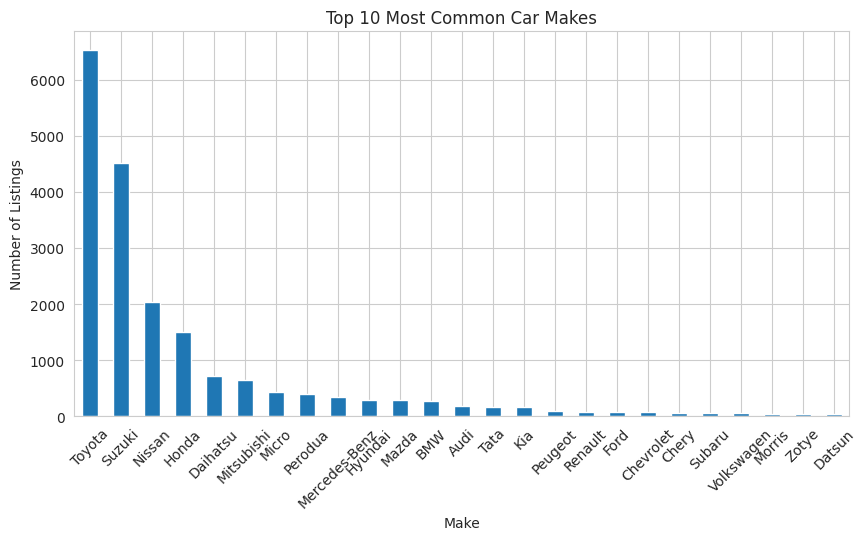

In [ ]:
import matplotlib.pyplot as plt

# Count top 10 makes
top_makes = merged_df["Make"].value_counts().head(25)

plt.figure(figsize=(10,5))
top_makes.plot(kind="bar")

plt.title("Top 10 Most Common Car Makes")
plt.xlabel("Make")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.show()

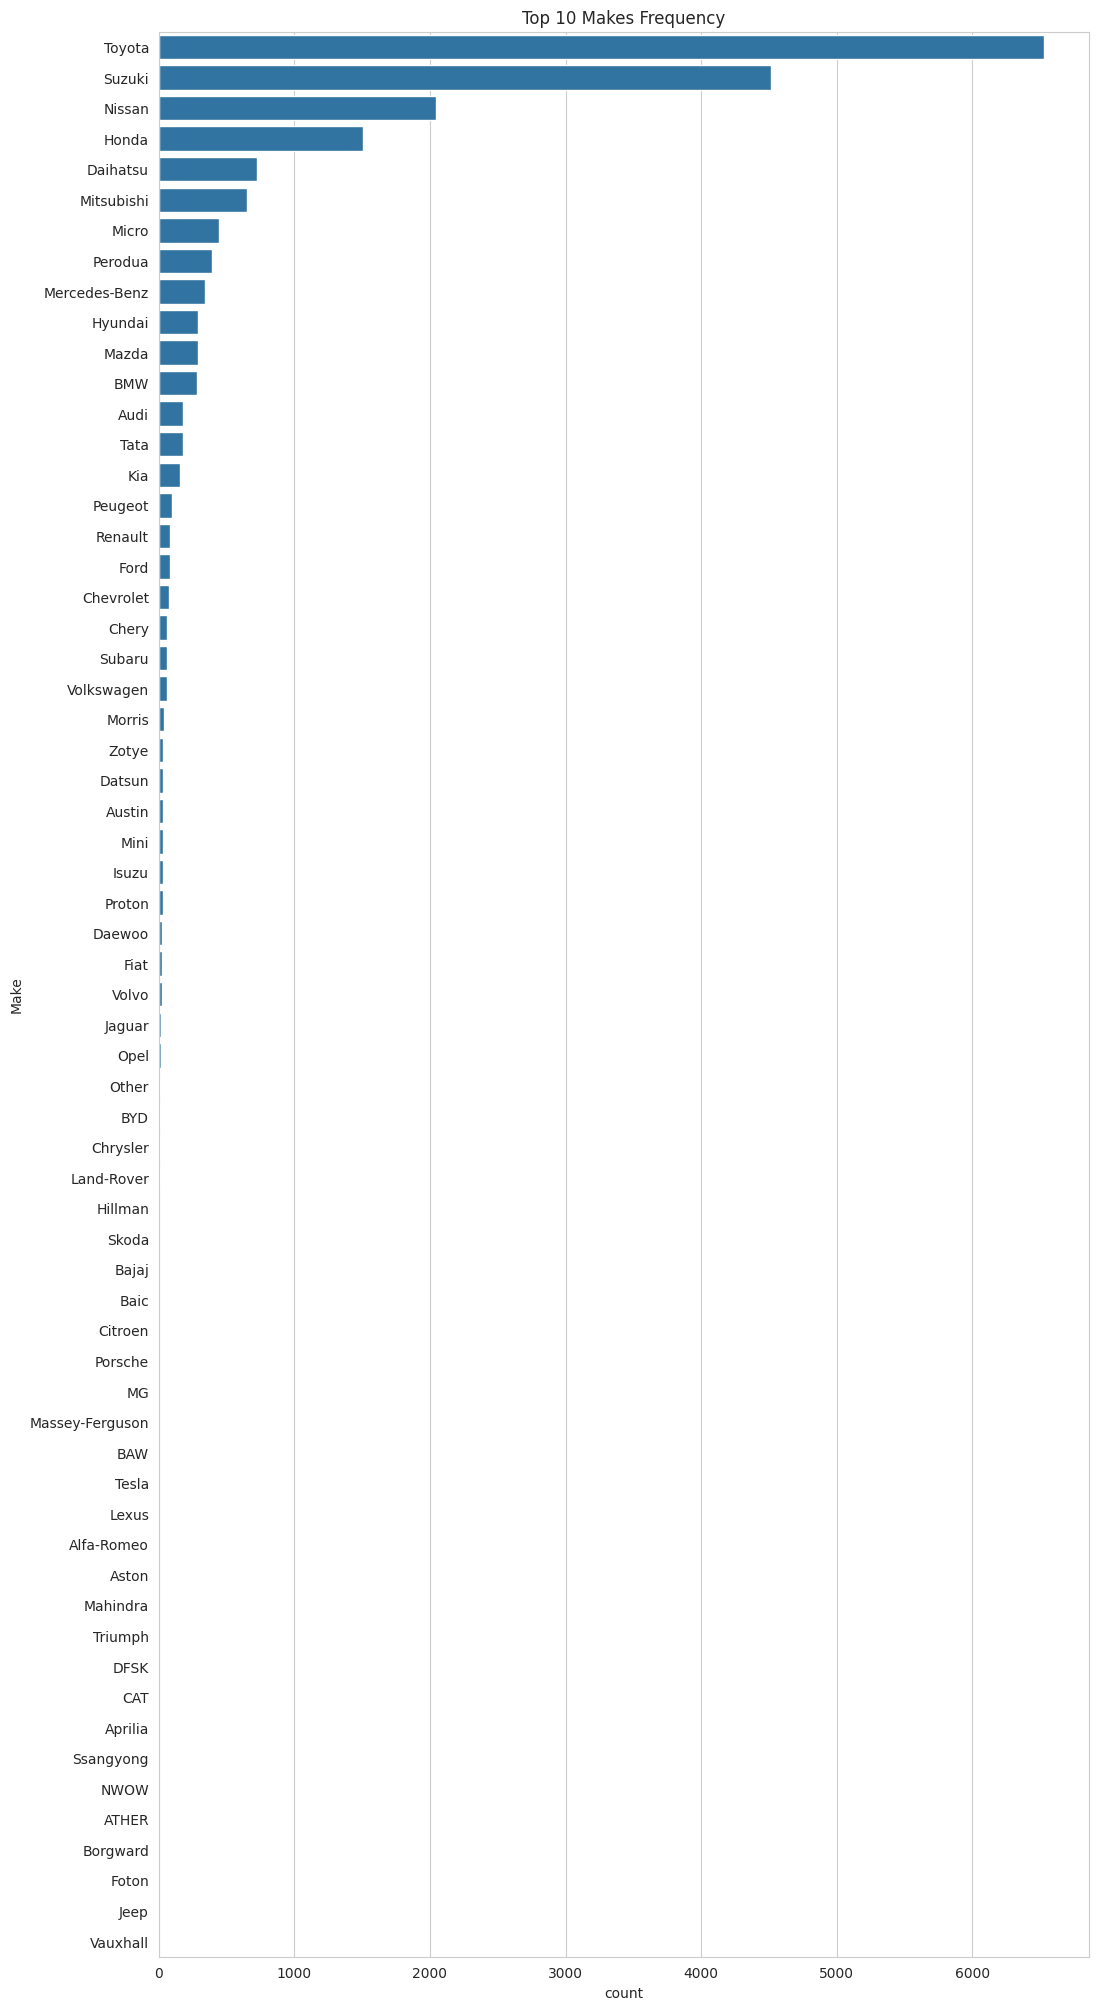

In [ ]:
plt.figure(figsize=(12,25))
sns.countplot(
    data=merged_df,
    y="Make",
    order=merged_df["Make"].value_counts().index
)

plt.title("Top 10 Makes Frequency")
plt.show()

### Engine (cc)

Inspecting the 'Engine (cc)' column for null values, unique non-numeric entries (like dashes or text), and their counts to assess data quality and prepare for type conversion.

In [ ]:
import numpy as np

# Count null values in 'Engine (cc)'
null_count_engine_cc = merged_df['Engine (cc)'].isnull().sum()
print(f"\n--- Null values in 'Engine (cc)': {null_count_engine_cc} ---")

# Identify unique non-numeric values in 'Engine (cc)'
# First, convert to string to handle all types uniformly for regex search
non_numeric_engine_cc = merged_df['Engine (cc)'].astype(str).str.contains(r'[^0-9.]', na=False)

unique_non_numeric_values = merged_df.loc[non_numeric_engine_cc, 'Engine (cc)'].unique()

print("\n--- Unique non-numeric values in 'Engine (cc)' ---")
if len(unique_non_numeric_values) > 0:
    print(unique_non_numeric_values)
    print("\n--- Value counts of unique non-numeric entries (top 10) ---")
    print(merged_df.loc[non_numeric_engine_cc, 'Engine (cc)'].value_counts().head(10))
else:
    print("No apparent non-numeric values found besides potential NaNs.")

# Also check how many rows are purely numeric after coercing errors to NaN
numeric_engine_cc = pd.to_numeric(merged_df['Engine (cc)'], errors='coerce')

print(f"\n--- Total entries: {len(merged_df)} ---")
print(f"--- Numeric entries (will convert to float/int): {numeric_engine_cc.count()} ---")
print(f"--- Non-numeric/NaN entries: {len(merged_df) - numeric_engine_cc.count()} ---")


--- Null values in 'Engine (cc)': 737 ---

--- Unique non-numeric values in 'Engine (cc)' ---
[nan]

--- Value counts of unique non-numeric entries (top 10) ---
Series([], Name: count, dtype: int64)

--- Total entries: 19465 ---
--- Numeric entries (will convert to float/int): 18728 ---
--- Non-numeric/NaN entries: 737 ---


### Engine (cc) - Strip spaces, Replace Dashes, and Convert to Numeric

In [ ]:
import numpy as np

# Strip spaces from 'Engine (cc)' and replace dashes/empty strings with NaN
merged_df['Engine (cc)'] = merged_df['Engine (cc)'].astype(str).str.strip()
merged_df['Engine (cc)'] = merged_df['Engine (cc)'].replace(['-', ''], np.nan)

# Convert 'Engine (cc)' to numeric, coercing errors to NaN
merged_df['Engine (cc)'] = pd.to_numeric(merged_df['Engine (cc)'], errors='coerce')

print("Engine (cc) column cleaned and converted to numeric.")
print("Updated info for Engine (cc) column:")
merged_df['Engine (cc)'].info()

Engine (cc) column cleaned and converted to numeric.
Updated info for Engine (cc) column:
<class 'pandas.core.series.Series'>
Index: 19465 entries, 0 to 19864
Series name: Engine (cc)
Non-Null Count  Dtype  
--------------  -----  
18728 non-null  float64
dtypes: float64(1)
memory usage: 304.1 KB


/tmp/ipython-input-2835492453.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df['Engine (cc)'] = merged_df['Engine (cc)'].astype(str).str.strip()
/tmp/ipython-input-2835492453.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df['Engine (cc)'] = merged_df['Engine (cc)'].replace(['-', ''], np.nan)
/tmp/ipython-input-2835492453.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

In [ ]:
import numpy as np

# Count null values in 'Engine (cc)'
null_count_engine_cc = merged_df['Engine (cc)'].isnull().sum()
print(f"\n--- Null values in 'Engine (cc)': {null_count_engine_cc} ---")

# Identify unique non-numeric values in 'Engine (cc)'
# Convert to string to handle all types uniformly for regex search
non_numeric_engine_cc = merged_df['Engine (cc)'].astype(str).str.contains(r'[^0-9.]', na=False)

unique_non_numeric_values = merged_df.loc[non_numeric_engine_cc, 'Engine (cc)'].unique()

print("\n--- Unique non-numeric values in 'Engine (cc)' ---")
if len(unique_non_numeric_values) > 0:
    print(unique_non_numeric_values)
    print("\n--- Value counts of unique non-numeric entries (top 10) ---")
    print(merged_df.loc[non_numeric_engine_cc, 'Engine (cc)'].value_counts().head(10))
else:
    print("No apparent non-numeric values found besides potential NaNs.")

# Also check how many rows are purely numeric after coercing errors to NaN
numeric_engine_cc = pd.to_numeric(merged_df['Engine (cc)'], errors='coerce')

print(f"\n--- Total entries: {len(merged_df)} ---")
print(f"--- Numeric entries (will convert to float/int): {numeric_engine_cc.count()} ---")
print(f"--- Non-numeric/NaN entries: {len(merged_df) - numeric_engine_cc.count()} ---")


--- Null values in 'Engine (cc)': 737 ---

--- Unique non-numeric values in 'Engine (cc)' ---
[nan]

--- Value counts of unique non-numeric entries (top 10) ---
Series([], Name: count, dtype: int64)

--- Total entries: 19465 ---
--- Numeric entries (will convert to float/int): 18728 ---
--- Non-numeric/NaN entries: 737 ---


### Engine (cc) - Remove Impossible Values

Filtering the 'Engine (cc)' column to retain only realistic values between 500 cc and 8000 cc.

In [ ]:
# Remove impossible engine values
merged_df = merged_df[
    (merged_df['Engine (cc)'].isna()) |
    ((merged_df['Engine (cc)'] >= 500) & (merged_df['Engine (cc)'] <= 8000))
]

print("Removed impossible 'Engine (cc)' values.")
print("Updated DataFrame head after filtering:")
print(merged_df.head())

Removed impossible 'Engine (cc)' values.
Updated DataFrame head after filtering:
                                               Title  \
0           Toyota Premio G Superior 2018 Car (Used)   
1                  Chevrolet Beat LT 2012 Car (Used)   
2  Mitsubishi EK Wagon G PILOT 2023 Car Unregiste...   
3              Suzuki Swift RS Turbo 2017 Car (Used)   
4                      Toyota Soluna 2000 Car (Used)   

                          Price        Make              Model     YOM  \
0                Rs. 15,500,000      Toyota  Premio G Superior  2018.0   
1  Rs. 3,950,000(Ongoing Lease)   Chevrolet            Beat LT  2012.0   
2                 Rs. 7,390,000  Mitsubishi   EK Wagon G PILOT  2023.0   
3                    Negotiable      Suzuki     Swift RS Turbo  2017.0   
4                 Rs. 3,290,000      Toyota             Soluna  2000.0   

  Mileage (km)       Gear Fuel Type  \
0       136500  Automatic    Petrol   
1       107000     Manual    Petrol   
2        15000  Auto

### Engine (cc) - Re-inspection after Cleaning

In [ ]:
print("\n--- Null values in 'Engine (cc)' after cleaning ---")
print(merged_df['Engine (cc)'].isnull().sum())

print("\n--- Descriptive statistics for 'Engine (cc)' after cleaning ---")
print(merged_df['Engine (cc)'].describe())


--- Null values in 'Engine (cc)' after cleaning ---
737

--- Descriptive statistics for 'Engine (cc)' after cleaning ---
count    18728.000000
mean      1225.481472
std        420.955856
min        500.000000
25%        990.000000
50%       1300.000000
75%       1500.000000
max       6600.000000
Name: Engine (cc), dtype: float64


In [ ]:
import numpy as np

# Count null values in 'Engine (cc)'
null_count_engine_cc = merged_df['Engine (cc)'].isnull().sum()
print(f"\n--- Null values in 'Engine (cc)': {null_count_engine_cc} ---")

# Identify unique non-numeric values in 'Engine (cc)'
# Convert to string to handle all types uniformly for regex search
non_numeric_engine_cc = merged_df['Engine (cc)'].astype(str).str.contains(r'[^0-9.]', na=False)

unique_non_numeric_values = merged_df.loc[non_numeric_engine_cc, 'Engine (cc)'].unique()

print("\n--- Unique non-numeric values in 'Engine (cc)' ---")
if len(unique_non_numeric_values) > 0:
    print(unique_non_numeric_values)
    print("\n--- Value counts of unique non-numeric entries (top 10) ---")
    print(merged_df.loc[non_numeric_engine_cc, 'Engine (cc)'].value_counts().head(10))
else:
    print("No apparent non-numeric values found besides potential NaNs.")

# Also check how many rows are purely numeric after coercing errors to NaN
numeric_engine_cc = pd.to_numeric(merged_df['Engine (cc)'], errors='coerce')

print(f"\n--- Total entries: {len(merged_df)} ---")
print(f"--- Numeric entries (will convert to float/int): {numeric_engine_cc.count()} ---")
print(f"--- Non-numeric/NaN entries: {len(merged_df) - numeric_engine_cc.count()} ---")


--- Null values in 'Engine (cc)': 737 ---

--- Unique non-numeric values in 'Engine (cc)' ---
[nan]

--- Value counts of unique non-numeric entries (top 10) ---
Series([], Name: count, dtype: int64)

--- Total entries: 19465 ---
--- Numeric entries (will convert to float/int): 18728 ---
--- Non-numeric/NaN entries: 737 ---


### Engine (cc) - Unique Values

In [ ]:
print("\n--- Unique values in 'Engine (cc)' ---")
print(merged_df['Engine (cc)'].unique())


--- Unique values in 'Engine (cc)' ---
[1500. 1200.  660. 1000. 1490. 1970. 2000. 1330. 1800.  650. 1300.   nan
 2190.  800. 1990. 1290. 1968.  990. 1590. 1341. 1400. 1240.  999. 2400.
 2500. 1343. 1600.  658.  850. 1331. 1991. 2200. 1450. 2155. 1650.  690.
 2100. 1197. 1700. 1596. 1100. 1598.  814. 1498. 1320. 1170. 1298.  996.
 1370. 1799.  625.  659. 1350. 1193. 1840. 1999. 1997. 1790. 1973. 1499.
 1980. 3200. 1690. 1299. 1984.  796.  900. 1295.  980. 1399. 1390. 1405.
 1497. 1900. 1599.  812. 1060. 4200. 1998. 1493. 2150. 1584. 1340. 1460.
 1270. 2180. 1070.  989. 2350.  624. 1332.  649.  655.  998. 3500. 3000.
 1050. 1495. 1360. 2143.  811. 2497.  736. 1075. 2800. 1472. 1308. 1496.
 3600. 1750. 1625. 1995.  600. 1329. 1395. 1480. 1950. 1220.  680. 1850.
 1130. 1796. 1597. 1250.  790. 1396.  988. 1066. 2490.  841. 1438. 1095.
 1896.  815. 1468. 1798.  803. 2979. 2888.  620. 2771. 2250.  670. 1296.
  647. 2140. 1945. 2290. 1979. 2600. 1380. 1975. 1595. 1587. 2700. 2770.
 2900. 2694

### Visualize Engine (cc) Distribution


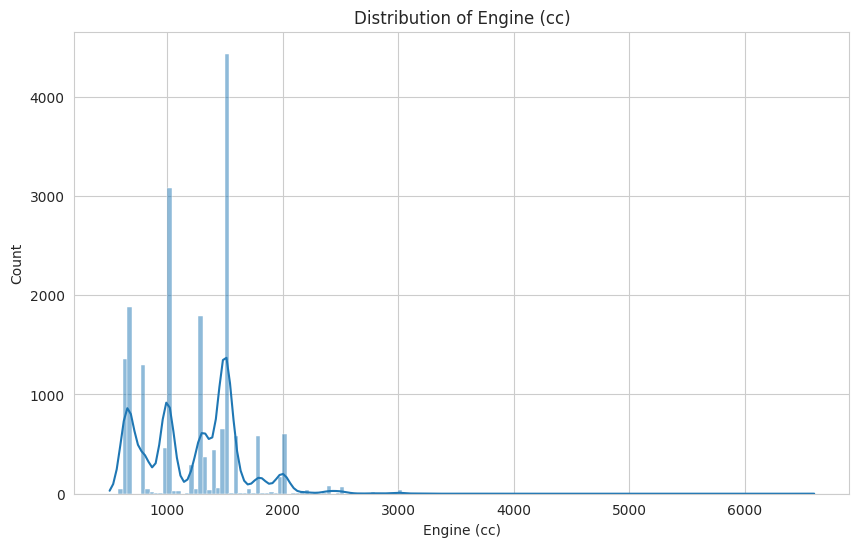

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(data=merged_df, x='Engine (cc)', kde=True)
plt.title('Distribution of Engine (cc)')
plt.xlabel('Engine (cc)')
plt.ylabel('Count')
plt.show()

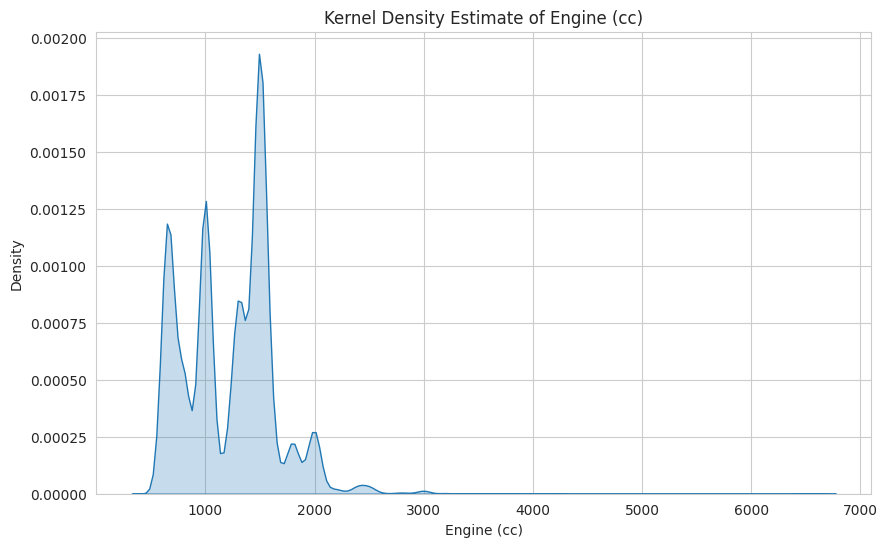

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Create a new figure for the plot with a suitable size
plt.figure(figsize=(10, 6))

# Generate a KDE plot for the 'Engine (cc)' column
sns.kdeplot(data=merged_df, x='Engine (cc)', fill=True)

# Set the title of the plot
plt.title('Kernel Density Estimate of Engine (cc)')

# Label the x-axis and y-axis
plt.xlabel('Engine (cc)')
plt.ylabel('Density')

# Display the plot
plt.show()

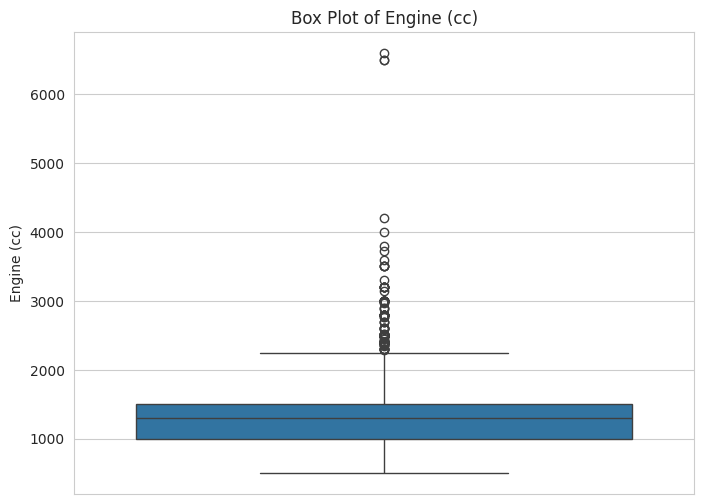

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))
sns.boxplot(y=merged_df['Engine (cc)'])

plt.title('Box Plot of Engine (cc)')
plt.ylabel('Engine (cc)')

plt.show()

Engine capacity values show a multimodal distribution, with dominant peaks at 660cc, 1000cc, and 1500cc, reflecting the prevalence of compact Japanese imports and mid-range sedans in the Sri Lankan resale market. Higher-capacity engines above 2500cc appear as rare outliers, corresponding to SUVs and luxury vehicle listings. To reduce noise and improve baseline regression stability, extreme engine values above 5000cc were excluded.

### Filter for High Engine (cc) Values

In [ ]:
high_cc_cars = merged_df[merged_df['Engine (cc)'] >= 4000]

print("\n--- Cars with Engine (cc) 4000 or more ---")
if not high_cc_cars.empty:
    print(f"Number of cars with Engine (cc) 4000 or more: {len(high_cc_cars)}")
    print(high_cc_cars.head())
    display(high_cc_cars)
else:
    print("No cars found with Engine (cc) 4000 or more.")


--- Cars with Engine (cc) 4000 or more ---
Number of cars with Engine (cc) 4000 or more: 5
                                                   Title  \
1214                        Chrysler 300 2012 Car (Used)   
14786  Suzuki Wagon R FX 2018 Car (Used)             ...   
14965  Suzuki Wagon R 2016 Car (Used)                ...   
16292  Suzuki Wagon R 2024 Car Unregistered (Recondit...   
17432  Mercedes-Benz Maybach S580 2025 Car Unregister...   

                                  Price           Make  \
1214                     Rs. 19,000,000       Chrysler   
14786    Rs. 6,100,000                          Suzuki   
14965  Negotiable                               Suzuki   
16292  Negotiable                               Suzuki   
17432    Rs. 270,000,000                 Mercedes-Benz   

                                       Model     YOM   Mileage (km)  \
1214                                     300  2012.0          33000   
14786  Wagon R FX                             2018.0  10

,Title,Price,Make,Model,YOM,Mileage (km),Gear,Fuel Type,Options,Engine (cc),Details
1214,Chrysler 300 2012 Car (Used),"Rs. 19,000,000",Chrysler,300,2012.0,33000,Automatic,Petrol,"AIR CONDITION, POWER STEERING, POWER MIRROR, P...",4200.0,Dankotuwa 77 77 83 955
14786,Suzuki Wagon R FX 2018 Car (Used) ...,"Rs. 6,100,000",Suzuki,Wagon R FX,2018.0,100000,Automatic,Hybrid,"AIR CONDITION, POWER STEERING, POWER MIRROR, P...",6600.0,Wagon R FX2018 /20181st owner100000kmAll recor...
14965,Suzuki Wagon R 2016 Car (Used) ...,Negotiable,Suzuki,Wagon R,2016.0,840000,Automatic,Hybrid,- ...,6500.0,-
16292,Suzuki Wagon R 2024 Car Unregistered (Recondit...,Negotiable,Suzuki,Wagon R,2024.0,10300,Automatic,Petrol,"AIR CONDITION, POWER STEERING, POWER MIRROR, P...",6500.0,*Push Start.* Safety feature* 2024* Clear Jaai...
17432,Mercedes-Benz Maybach S580 2025 Car Unregister...,"Rs. 270,000,000",Mercedes-Benz,Maybach S580,2025.0,-,Automatic,Petrol,"AIR CONDITION, POWER STEERING, POWER MIRROR, P...",4000.0,Mercedes-Maybach S580 FIRST CLASS4.0L twin-tur...


## Inspect and Filter 'Suzuki' Cars with High Engine (cc)

In [ ]:
suzuki_high_cc_3000 = merged_df[(merged_df['Make'] == 'Suzuki') & (merged_df['Engine (cc)'] > 3000)]
print(f"Number of Suzuki cars with Engine (cc) > 3000: {len(suzuki_high_cc_3000)}")

Number of Suzuki cars with Engine (cc) > 3000: 3


Removing the rows where the 'Make' is 'Suzuki' and the 'Engine (cc)' is greater than 4000.

In [ ]:
initial_rows = len(merged_df)
merged_df = merged_df[~((merged_df['Make'] == 'Suzuki') & (merged_df['Engine (cc)'] > 4000))]

print(f"Removed {initial_rows - len(merged_df)} rows where Make is Suzuki and Engine (cc) > 4000.")
print("\nUpdated DataFrame head after removing specified Suzuki cars:")
print(merged_df.head())
print("\nUpdated DataFrame info:")
merged_df.info()

Removed 3 rows where Make is Suzuki and Engine (cc) > 4000.

Updated DataFrame head after removing specified Suzuki cars:
                                               Title  \
0           Toyota Premio G Superior 2018 Car (Used)   
1                  Chevrolet Beat LT 2012 Car (Used)   
2  Mitsubishi EK Wagon G PILOT 2023 Car Unregiste...   
3              Suzuki Swift RS Turbo 2017 Car (Used)   
4                      Toyota Soluna 2000 Car (Used)   

                          Price        Make              Model     YOM  \
0                Rs. 15,500,000      Toyota  Premio G Superior  2018.0   
1  Rs. 3,950,000(Ongoing Lease)   Chevrolet            Beat LT  2012.0   
2                 Rs. 7,390,000  Mitsubishi   EK Wagon G PILOT  2023.0   
3                    Negotiable      Suzuki     Swift RS Turbo  2017.0   
4                 Rs. 3,290,000      Toyota             Soluna  2000.0   

  Mileage (km)       Gear Fuel Type  \
0       136500  Automatic    Petrol   
1       107000    

### High CC Cars

In [ ]:
high_cc_cars = merged_df[merged_df['Engine (cc)'] >= 3000]

print("\n--- Cars with Engine (cc) 4000 or more ---")
if not high_cc_cars.empty:
    print(f"Number of cars with Engine (cc) 4000 or more: {len(high_cc_cars)}")
    display(high_cc_cars)
else:
    print("No cars found with Engine (cc) 4000 or more.")


--- Cars with Engine (cc) 4000 or more ---
Number of cars with Engine (cc) 4000 or more: 50


,Title,Price,Make,Model,YOM,Mileage (km),Gear,Fuel Type,Options,Engine (cc),Details
837,Mercedes-Benz W140 S320 1993 Car (Used),"Rs. 6,500,000",Mercedes-Benz,W140 S320,1993.0,235000,Automatic,Petrol,-,3200.0,Mercedes Benz W140 S3201993 Brand New Imported...
1214,Chrysler 300 2012 Car (Used),"Rs. 19,000,000",Chrysler,300,2012.0,33000,Automatic,Petrol,"AIR CONDITION, POWER STEERING, POWER MIRROR, P...",4200.0,Dankotuwa 77 77 83 955
1658,Mercedes-Benz S 400 2014 Car (Used),"Rs. 42,500,000",Mercedes-Benz,S 400,2014.0,32000,Automatic,Petrol,"AIR CONDITION, POWER STEERING, POWER MIRROR, P...",3500.0,Beige interior fully loaded carsunroof moonroo...
1696,BMW 530i 1999 Car (Used),Negotiable,BMW,530i,1999.0,135000,Automatic,Petrol,"AIR CONDITION, POWER STEERING, POWER MIRROR, P...",3000.0,Fully restored E39 530i autoBrand new conditio...
1718,BMW Z4 SDrive35is 2012 Car (Used),"Rs. 32,500,000",BMW,Z4 SDrive35is,2012.0,37000,Automatic,Petrol,"AIR CONDITION, POWER STEERING, POWER MIRROR, P...",3000.0,BMW Z4 sDrive35is 2012 – 3.0L Twin-Turbo Roads...
2184,Porsche Panamera S 2013 Car (Used),"Rs. 33,000,000",Porsche,Panamera S,2013.0,63000,Automatic,Hybrid,"AIR CONDITION, POWER STEERING, POWER MIRROR, P...",3000.0,🚘🚘 KUSUM CAR SALE 🚘⁣⁣⁣⁣PORSCHE PANAMERA S HYBR...
2248,Chrysler C300 2012 Car (Used),"Rs. 18,500,000",Chrysler,C300,2012.0,108000,Automatic,Petrol,-,3600.0,Chrysler 3.6 Litre V6 2013 Model Facelift Full...
2373,Mercedes-Benz S350 2006 Car (Used),"Rs. 19,500,000",Mercedes-Benz,S350,2006.0,153000,Automatic,Petrol,-,3500.0,This vehicle looks brand new and has been conv...
2565,Mercedes-Benz S320L W220 2004 Car (Used),"Rs. 11,200,000",Mercedes-Benz,S320L W220,2004.0,190000,Automatic,Petrol,-,3200.0,⭕️ Expecting 112 lakhs.Genuine buyer only plea...
2640,Jaguar XF 3.0- 2014 Car (Used),Negotiable,Jaguar,XF 3.0-,2014.0,19000,Automatic,Petrol,"AIR CONDITION, POWER STEERING, POWER MIRROR, P...",3000.0,COMPANY CHAIRMAN OWNED AND LOWEST MILEAGE XF I...


In [ ]:
print("\n--- Unique 'Make' values in `high_cc_cars` ---")
if not high_cc_cars.empty:
    print(high_cc_cars['Make'].unique())
else:
    print("The `high_cc_cars` DataFrame is empty.")


--- Unique 'Make' values in `high_cc_cars` ---
['Mercedes-Benz' 'Chrysler' 'BMW' 'Porsche' 'Jaguar' 'Toyota' 'Nissan']


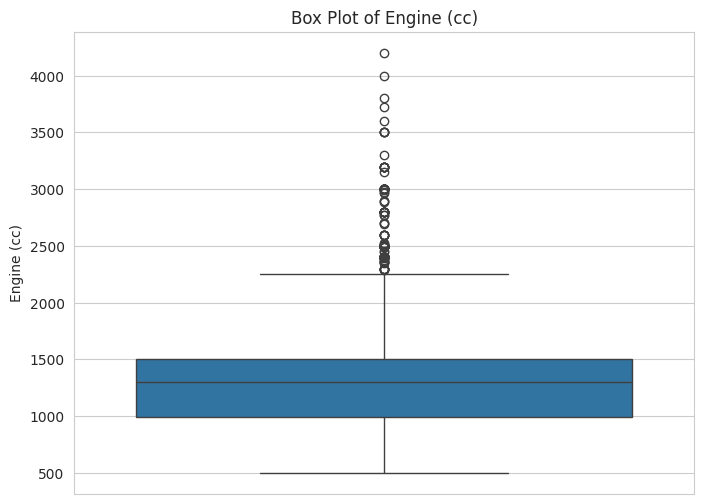

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))
sns.boxplot(y=merged_df['Engine (cc)'])

plt.title('Box Plot of Engine (cc)')
plt.ylabel('Engine (cc)')

plt.show()

In [ ]:
merged_df = merged_df[
    (merged_df["Engine (cc)"] >= 600) &
    (merged_df["Engine (cc)"] < 3500)
]

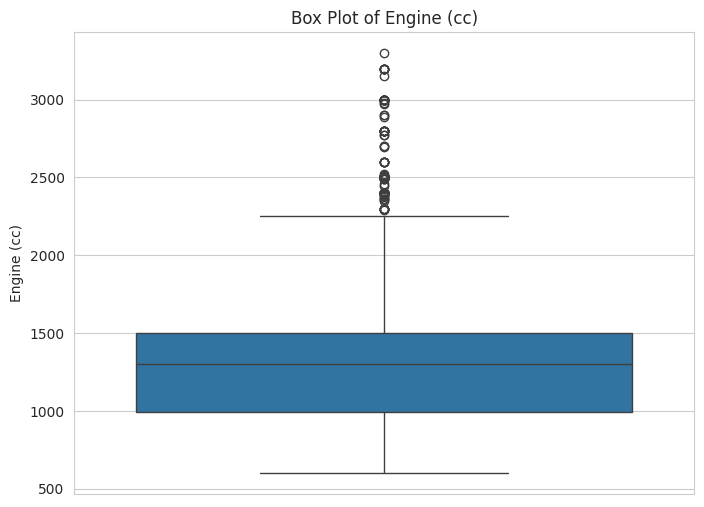

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))
sns.boxplot(y=merged_df['Engine (cc)'])

plt.title('Box Plot of Engine (cc)')
plt.ylabel('Engine (cc)')

plt.show()

To improve baseline regression stability, vehicles with engine capacities ≥3500cc were excluded, as they represent a rare luxury segment with disproportionately high prices. The resulting dataset reflects the mainstream Sri Lankan resale market, dominated by 1000–1500cc vehicles.

### Milage

In [ ]:
import numpy as np

# Count null values in 'Mileage (km)'
null_count_mileage_km = merged_df['Mileage (km)'].isnull().sum()
print(f"\n--- Null values in 'Mileage (km)': {null_count_mileage_km} ---")


--- Null values in 'Mileage (km)': 0 ---


In [ ]:

# Identify unique non-numeric values in 'Mileage (km)'
# Convert to string to handle all types uniformly for regex search, excluding NaN for initial filter
non_numeric_mileage_km = merged_df['Mileage (km)'].astype(str).str.contains(r'[^0-9.]', na=False)

unique_non_numeric_values = merged_df.loc[non_numeric_mileage_km, 'Mileage (km)'].unique()

print("\n--- Unique non-numeric values in 'Mileage (km)' ---")
if len(unique_non_numeric_values) > 0:
    print(unique_non_numeric_values)
    print("\n--- Value counts of unique non-numeric entries (top 10) ---")
    print(merged_df.loc[non_numeric_mileage_km, 'Mileage (km)'].value_counts().head(10))
else:
    print("No apparent non-numeric values found besides potential NaNs.")


--- Unique non-numeric values in 'Mileage (km)' ---
['-' '1600         ' '107000       ' ... '140          ' '1400000      '
 '155900       ']

--- Value counts of unique non-numeric entries (top 10) ---
Mileage (km)
-                652
-                641
150000           142
100000           133
200000           130
140000           100
4000              97
120000            90
160000            89
110000            82
Name: count, dtype: int64


In [ ]:
# Also check how many rows are purely numeric after coercing errors to NaN
numeric_mileage_km = pd.to_numeric(merged_df['Mileage (km)'], errors='coerce')

print(f"\n--- Total entries: {len(merged_df)} ---")
print(f"--- Numeric entries (will convert to float/int): {numeric_mileage_km.count()} ---")
print(f"--- Non-numeric/NaN entries: {len(merged_df) - numeric_mileage_km.count()} ---")


--- Total entries: 18713 ---
--- Numeric entries (will convert to float/int): 17420 ---
--- Non-numeric/NaN entries: 1293 ---


In [ ]:
merged_df["Mileage (km)"] = merged_df["Mileage (km)"].astype(str).str.strip()

In [ ]:
merged_df["Mileage (km)"] = merged_df["Mileage (km)"].replace("-", np.nan)

In [ ]:
merged_df["Mileage (km)"] = pd.to_numeric(
    merged_df["Mileage (km)"],
    errors="coerce"
)

### Visualize Mileage (km) Outliers with Box Plot

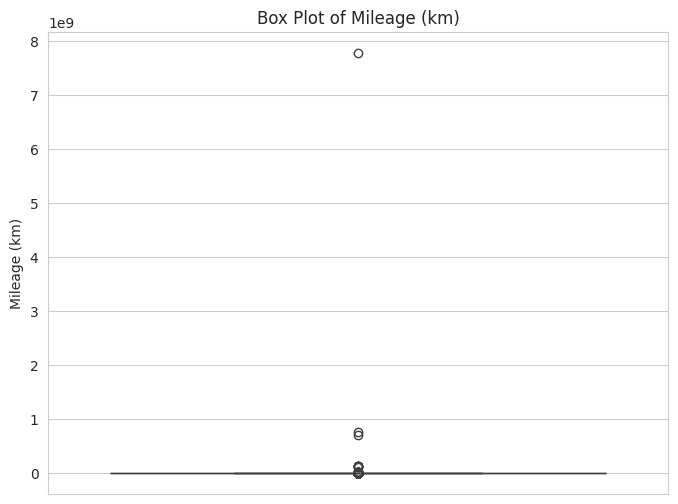

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))
sns.boxplot(y=merged_df['Mileage (km)'])

plt.title('Box Plot of Mileage (km)')
plt.ylabel('Mileage (km)')

plt.show()

Inspecting the actual data points that represent these extreme values.



In [ ]:
merged_df.sort_values("Mileage (km)", ascending=False).head(10)

,Title,Price,Make,Model,YOM,Mileage (km),Gear,Fuel Type,Options,Engine (cc),Details
8623,Toyota Carina At 192 1994 Car (Used),"Rs. 29,750,000",Toyota,Carina At 192,1994.0,7.777778e+09,Automatic,Petrol,"AIR CONDITION, POWER STEERING, POWER MIRROR, P...",1500.0,-
5982,Nissan Sunny CB12 1989 Car (Used),"Rs. 1,610,000",Nissan,Sunny CB12,1989.0,7.531418e+08,Manual,Petrol,-,1400.0,Very good condition. Carefully used. All repai...
18090,Peugeot 504 L 1974 Car (Used) ...,Negotiable,Peugeot,504 L,1974.0,7.077227e+08,Manual,Petrol,POWER WINDOW ...,2000.0,Peugeot 504Well-maintained Original condition ...
4048,Hyundai Excel 1992 Car (Used),"Rs. 1,025,000",Hyundai,Excel,1992.0,1.234568e+08,Manual,Petrol,"AIR CONDITION, POWER STEERING, POWER WINDOW",1500.0,Hyundai Excel 1992-BrandNew▪️ඉක්මනින් විකිණීමට...
14673,Kia Rio 2002 Car (Used) ...,"Rs. 2,250,000",Kia,Rio,2002.0,1.234568e+08,Manual,Petrol,"AIR CONDITION, POWER STEERING, POWER WINDOW ...",1500.0,🚘 Mfc Year-2002.🚘 Fuel-Petrol.🚘 Engine. Capaci...
4118,Hyundai Excel 1992 Car (Used),"Rs. 1,025,000",Hyundai,Excel,1992.0,1.234568e+08,Manual,Petrol,"AIR CONDITION, POWER STEERING, POWER WINDOW",1500.0,Hyundai Excel 1992-BrandNew▪️ඉක්මනින් විකිණීමට...
11496,Toyota Corolla 1972 Car (Used) ...,"Rs. 500,000",Toyota,Corolla,1972.0,1.234568e+08,Manual,Petrol,- ...,1200.0,මිල ගනන් සාකච්ඡා කරගත හැක. අමතන්න
16708,Honda Accord 1987 Car (Used) ...,"Rs. 1,585,000",Honda,Accord,1987.0,1.111111e+08,Automatic,Petrol,"AIR CONDITION, POWER STEERING, POWER MIRROR, P...",1600.0,Honda Accord15 number .Full Option..Enjin💯 ..C...
857,Mitsubishi C12 1985 Car (Used),"Rs. 1,190,000",Mitsubishi,C12,1985.0,1.111111e+08,Manual,Petrol,"AIR CONDITION, POWER STEERING",1500.0,Lancer c122nd ownerSuperb conditionRunning 100...
4711,Toyota Vitz 2014 Car (Used),"Rs. 6,950,000",Toyota,Vitz,2014.0,1.740000e+07,Automatic,Petrol,-,1000.0,Lady Driven1st ownerAccident freeGenuine Mileage


Filtering the DataFrame to exclude any entries where the mileage is greater than 500,000 km, as these values are likely erroneous.


In [ ]:
merged_df = merged_df[
    (merged_df["Mileage (km)"] > 0) &
    (merged_df["Mileage (km)"] <= 500000)
]

In [ ]:
print("Max mileage:", merged_df["Mileage (km)"].max())

Max mileage: 500000.0


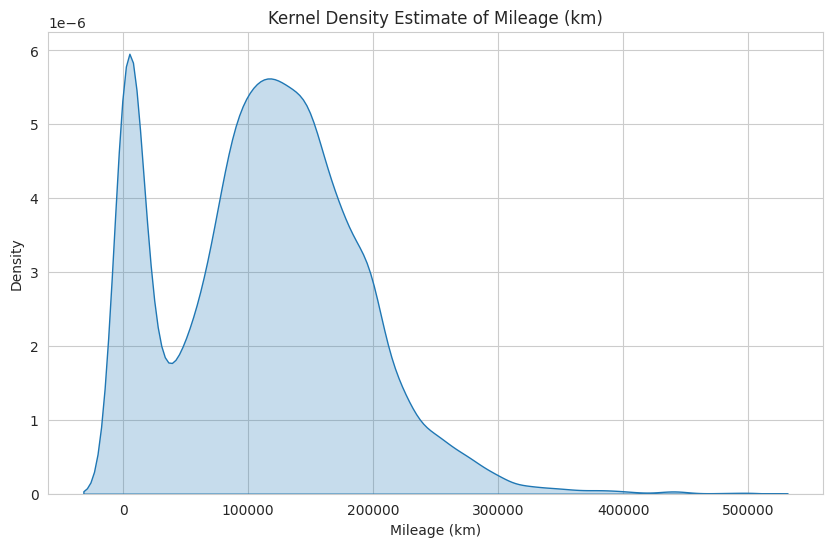

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Create a new figure for the plot with a suitable size
plt.figure(figsize=(10, 6))

# Generate a Kernel Density Estimate (KDE) plot for the 'Mileage (km)' column
sns.kdeplot(data=merged_df, x='Mileage (km)', fill=True)

# Set the title of the plot
plt.title('Kernel Density Estimate of Mileage (km)')

# Label the x-axis and y-axis
plt.xlabel('Mileage (km)')
plt.ylabel('Density')

# Display the plot
plt.show()

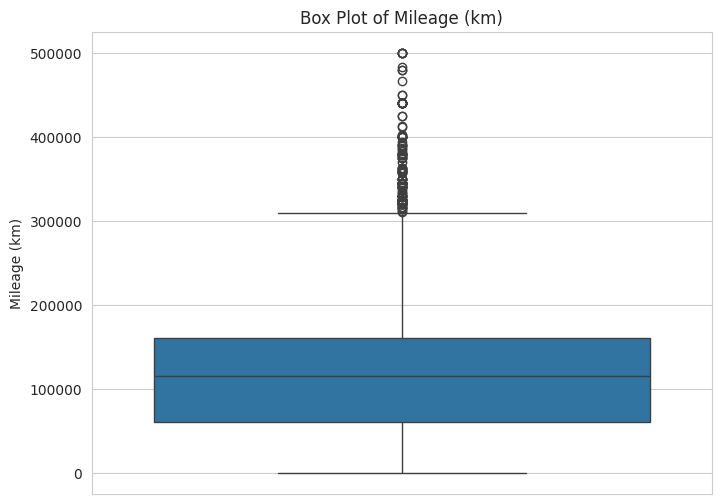

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))
sns.boxplot(y=merged_df['Mileage (km)'])

plt.title('Box Plot of Mileage (km)')
plt.ylabel('Mileage (km)')

plt.show()

In [ ]:
print("Minimum mileage:", merged_df["Mileage (km)"].min())

Minimum mileage: 1.0


In [ ]:
merged_df[merged_df["Mileage (km)"] > 500000]

,Title,Price,Make,Model,YOM,Mileage (km),Gear,Fuel Type,Options,Engine (cc),Details


In [ ]:
print("Max mileage now:", merged_df["Mileage (km)"].max())
print("Rows remaining:", merged_df.shape)

Max mileage now: 500000.0
Rows remaining: (17044, 11)


In [ ]:
print("Missing mileage:", merged_df["Mileage (km)"].isnull().sum())

Missing mileage: 0


Mileage values above 500,000 km were removed as they represent extreme outliers (<1% of listings) and may reflect seller input errors. Filtering improved model robustness and reduced skew in the mileage distribution.

In [ ]:
print(merged_df.isnull().sum())

Title           0
Price           0
Make            0
Model           0
YOM             0
Mileage (km)    0
Gear            0
Fuel Type       0
Options         0
Engine (cc)     0
Details         0
dtype: int64


### Fuel Type

In [ ]:
print("\n--- Unique Fuel Types ---")
print(merged_df['Fuel Type'].unique())

print("\n--- Counts of Each Fuel Type ---")
print(merged_df['Fuel Type'].value_counts())


--- Unique Fuel Types ---
['Petrol' 'Diesel' 'Hybrid' 'Electric' 'Gas' 'Petrol    ' 'Hybrid    '
 'Diesel    ' 'Electric  ' 'Gas       ']

--- Counts of Each Fuel Type ---
Fuel Type
Petrol        7362
Petrol        6043
Hybrid        1526
Hybrid        1349
Diesel         405
Diesel         323
Electric        22
Electric        11
Gas              2
Gas              1
Name: count, dtype: int64


In [ ]:
# Strip spaces
merged_df["Fuel Type"] = merged_df["Fuel Type"].astype(str).str.strip()

# Replace empty or nan-like strings with real NaN
merged_df["Fuel Type"] = merged_df["Fuel Type"].replace(["", "nan", "None"], np.nan)

# Drop missing fuel types
#merged_df = merged_df.dropna(subset=["Fuel Type"])

In [ ]:
print(merged_df["Fuel Type"].unique())
print(merged_df["Fuel Type"].value_counts())

['Petrol' 'Diesel' 'Hybrid' 'Electric' 'Gas']
Fuel Type
Petrol      13405
Hybrid       2875
Diesel        728
Electric       33
Gas             3
Name: count, dtype: int64


In [ ]:
merged_df["Fuel Type"] = merged_df["Fuel Type"].replace({
    "Gas": "Other",
    "Electric": "Other"
})

In [ ]:
print(merged_df["Fuel Type"].unique())
print(merged_df["Fuel Type"].value_counts())

['Petrol' 'Diesel' 'Hybrid' 'Other']
Fuel Type
Petrol    13405
Hybrid     2875
Diesel      728
Other        36
Name: count, dtype: int64


In [ ]:
print("Missing F type:", merged_df["Fuel Type"].isnull().sum())

Missing F type: 0


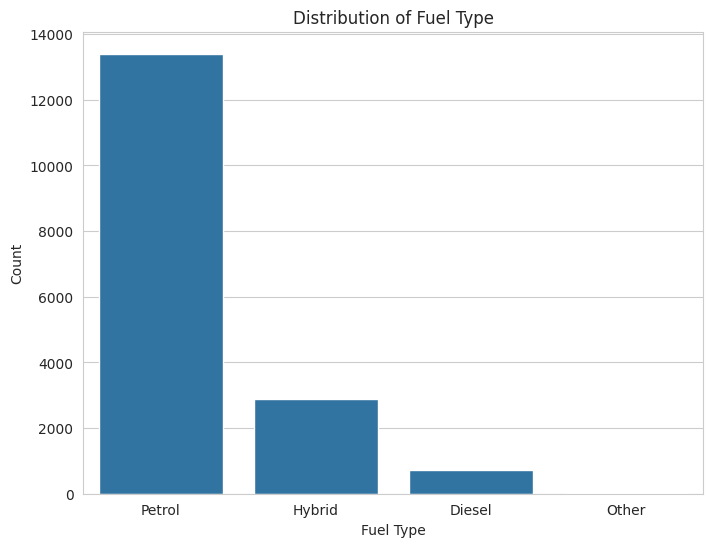

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))
sns.countplot(data=merged_df, x='Fuel Type', order=merged_df['Fuel Type'].value_counts().index)

plt.title('Distribution of Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Count')

plt.show()

### Gear

In [ ]:
print("\n--- Unique Gear Types ---")
print(merged_df["Gear"].unique())

print("\n--- Counts of Each Gear Type ---")
print(merged_df["Gear"].value_counts())


--- Unique Gear Types ---
['Automatic' 'Manual' 'Automatic ' 'Manual    ' '          ']

--- Counts of Each Gear Type ---
Gear
Automatic     6916
Automatic     5769
Manual        2389
Manual        1969
                 1
Name: count, dtype: int64


In [ ]:
# Strip whitespace
merged_df["Gear"] = merged_df["Gear"].astype(str).str.strip()

# Replace empty/invalid entries with NaN
merged_df["Gear"] = merged_df["Gear"].replace(["", "nan", "None"], np.nan)

# Drop missing gear rows
merged_df = merged_df.dropna(subset=["Gear"])

In [ ]:
merged_df = merged_df[merged_df["Gear"].isin(["Automatic", "Manual", "CVT"])]

In [ ]:
print(merged_df["Gear"].unique())
print(merged_df["Gear"].value_counts())

['Automatic' 'Manual']
Gear
Automatic    12685
Manual        4358
Name: count, dtype: int64


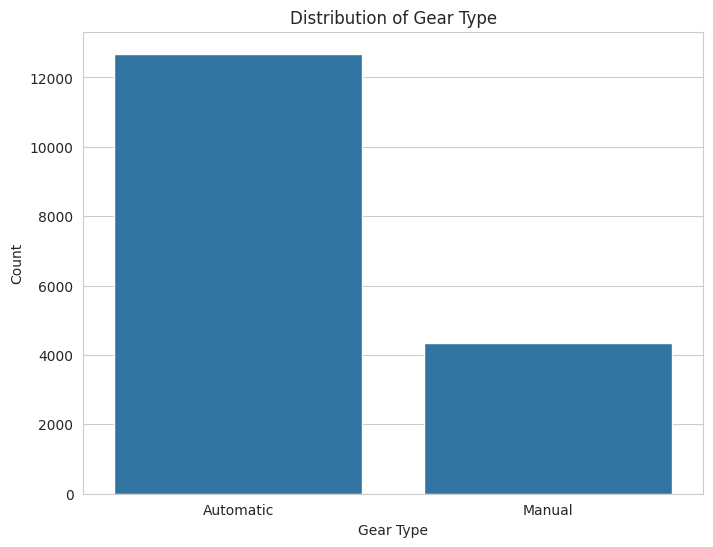

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))
sns.countplot(data=merged_df, x='Gear', order=merged_df['Gear'].value_counts().index)

plt.title('Distribution of Gear Type')
plt.xlabel('Gear Type')
plt.ylabel('Count')

plt.show()

Categorical variables contained inconsistent whitespace formatting due to scraping. String normalization (strip + validation) was applied to ensure consistent category encoding.

### Year of Manufacture (YOM)


--- Descriptive Statistics for 'YOM' ---
count    17043.000000
mean      2007.953060
std         66.281232
min          0.000000
25%       2005.000000
50%       2013.000000
75%       2017.000000
max       2550.000000
Name: YOM, dtype: float64

--- Unique values in 'YOM' ---
[2018. 2012. 2023. 2017. 2000. 2003. 1991. 1996. 2007. 1997. 2016. 2013.
 2002. 2024. 2008. 2015. 1999. 2001. 2020. 2014. 1998. 2010. 1992. 1990.
 2005. 2025. 2004. 1985. 2009. 2011. 2006. 1993. 1971. 1974. 2019. 1984.
 1980. 2022. 1989. 1986. 1968. 1981. 1982. 1983. 1995. 1966. 1994. 1988.
 1987. 1979. 1949. 1973.    0. 1970. 1960. 1977. 1978. 1976. 2026. 1965.
 2021. 1959. 1975. 1954. 1972. 1969. 1950. 1953. 1956. 1957. 1962. 1955.
 1967. 1958. 1900. 2550. 1948. 1964. 1961.]


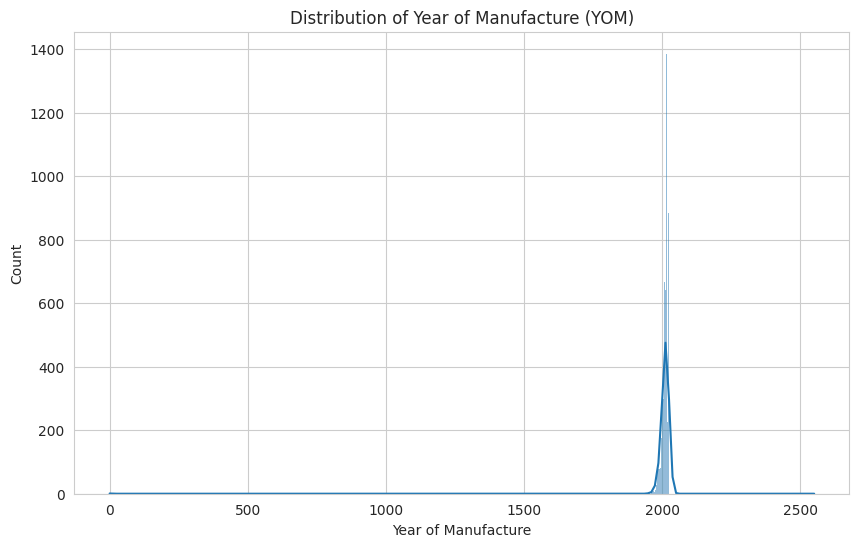

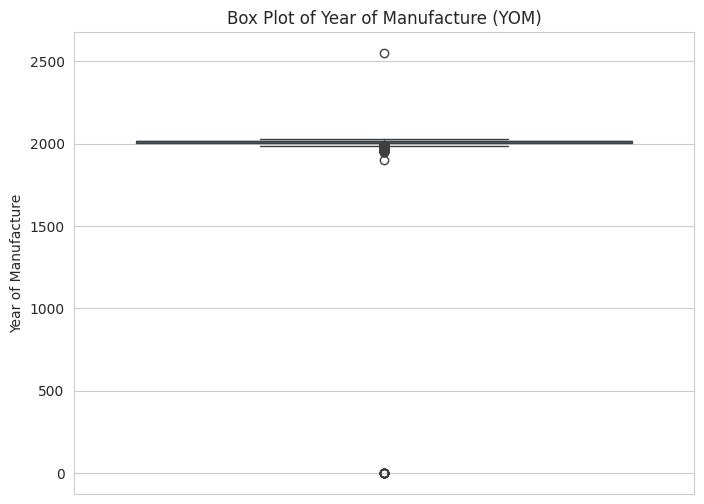

In [ ]:
print("\n--- Descriptive Statistics for 'YOM' ---")
print(merged_df['YOM'].describe())

print("\n--- Unique values in 'YOM' ---")
print(merged_df['YOM'].unique())

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Histogram for 'YOM'
plt.figure(figsize=(10, 6))
sns.histplot(data=merged_df, x='YOM', kde=True)
plt.title('Distribution of Year of Manufacture (YOM)')
plt.xlabel('Year of Manufacture')
plt.ylabel('Count')
plt.show()

# Box Plot for 'YOM'
plt.figure(figsize=(8, 6))
sns.boxplot(y=merged_df['YOM'])
plt.title('Box Plot of Year of Manufacture (YOM)')
plt.ylabel('Year of Manufacture')
plt.show()

In [ ]:
merged_df = merged_df[
    (merged_df["YOM"] >= 1960) &
    (merged_df["YOM"] <= 2026)
]

In [ ]:
print("Min YOM:", merged_df["YOM"].min())
print("Max YOM:", merged_df["YOM"].max())
print("Rows remaining:", merged_df.shape)

Min YOM: 1960.0
Max YOM: 2026.0
Rows remaining: (16994, 11)


In [ ]:
merged_df = merged_df[merged_df["YOM"] >= 1990]

A small number of invalid manufacturing years (e.g., 0 and 2550) were detected due to listing input errors. These were removed using domain-informed bounds (1960–2026) to ensure realistic temporal consistency.


--- Descriptive Statistics for 'YOM' ---
count    16067.000000
mean      2011.713076
std          8.175558
min       1990.000000
25%       2007.000000
50%       2013.000000
75%       2017.000000
max       2026.000000
Name: YOM, dtype: float64

--- Unique values in 'YOM' ---
[2018. 2012. 2023. 2017. 2000. 2003. 1991. 1996. 2007. 1997. 2016. 2013.
 2002. 2024. 2008. 2015. 1999. 2001. 2020. 2014. 1998. 2010. 1992. 1990.
 2005. 2025. 2004. 2009. 2011. 2006. 1993. 2019. 2022. 1995. 1994. 2026.
 2021.]


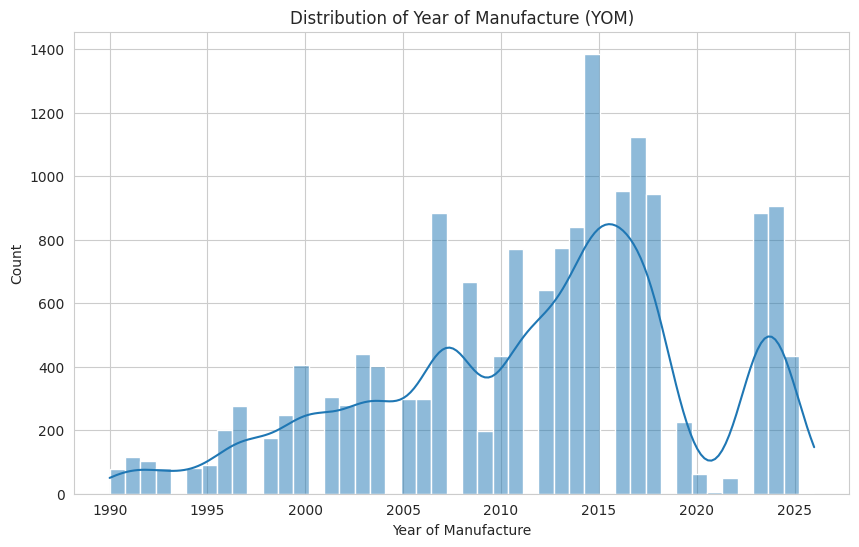

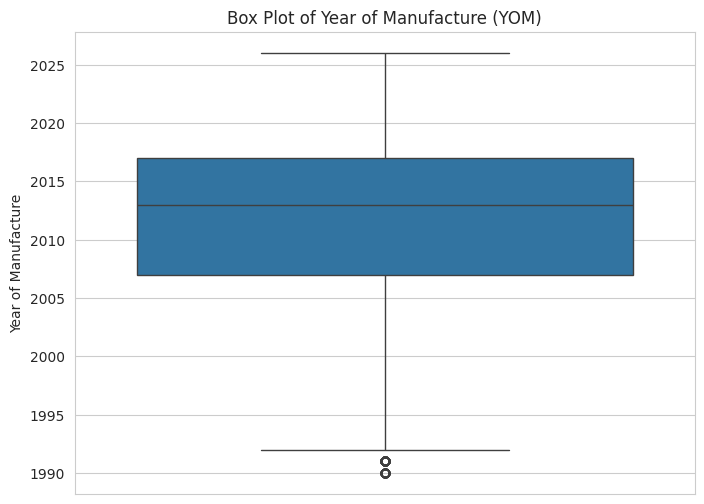

In [ ]:
print("\n--- Descriptive Statistics for 'YOM' ---")
print(merged_df['YOM'].describe())

print("\n--- Unique values in 'YOM' ---")
print(merged_df['YOM'].unique())

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Histogram for 'YOM'
plt.figure(figsize=(10, 6))
sns.histplot(data=merged_df, x='YOM', kde=True)
plt.title('Distribution of Year of Manufacture (YOM)')
plt.xlabel('Year of Manufacture')
plt.ylabel('Count')
plt.show()

# Box Plot for 'YOM'
plt.figure(figsize=(8, 6))
sns.boxplot(y=merged_df['YOM'])
plt.title('Box Plot of Year of Manufacture (YOM)')
plt.ylabel('Year of Manufacture')
plt.show()

### Creating a 'Vehicle Age' feature

In [ ]:
merged_df["Vehicle Age"] = 2026 - merged_df["YOM"]

In [ ]:
merged_df.head()

,Title,Price,Make,Model,YOM,Mileage (km),Gear,Fuel Type,Options,Engine (cc),Details,Vehicle Age
0,Toyota Premio G Superior 2018 Car (Used),"Rs. 15,500,000",Toyota,Premio G Superior,2018.0,136500.0,Automatic,Petrol,"AIR CONDITION, POWER STEERING, POWER MIRROR, P...",1500.0,"First owner, personally used vehicle, Company ...",8.0
1,Chevrolet Beat LT 2012 Car (Used),"Rs. 3,950,000(Ongoing Lease)",Chevrolet,Beat LT,2012.0,107000.0,Manual,Petrol,"AIR CONDITION, POWER STEERING, POWER MIRROR, P...",1200.0,කරුණාකර හොදින් කියවා WhatsApp පණිවුඩ මගින් විස...,14.0
2,Mitsubishi EK Wagon G PILOT 2023 Car Unregiste...,"Rs. 7,390,000",Mitsubishi,EK Wagon G PILOT,2023.0,15000.0,Automatic,Petrol,"AIR CONDITION, POWER STEERING, POWER MIRROR, P...",660.0,MITSUBISHI EK Wagon G GradePush Start/ AUTO Pi...,3.0
3,Suzuki Swift RS Turbo 2017 Car (Used),Negotiable,Suzuki,Swift RS Turbo,2017.0,106500.0,Automatic,Petrol,"AIR CONDITION, POWER STEERING, POWER MIRROR, P...",1000.0,1st owner100% accident freeExcellent body cond...,9.0
4,Toyota Soluna 2000 Car (Used),"Rs. 3,290,000",Toyota,Soluna,2000.0,149003.0,Manual,Petrol,"AIR CONDITION, POWER STEERING",1500.0,🔶️Toyota Soluna🔶️2000 Brandnew🔶️1500cc 5fwd🔶️A...,26.0


The analysis of the 'YOM' (Year of Manufacture) column revealed that after filtering for realistic values, its distribution is skewed towards newer vehicles, with a significant concentration around the 2013-2017 range, and a long tail extending to older models. The descriptive statistics confirm a mean YOM of 2011.7, ranging from 1990 to 2026. The `Vehicle Age` column was derived from `YOM`, so its distribution and statistical properties will mirror `YOM` but be inversely related to the year. The descriptive statistics and visualizations of `Vehicle Age` will further clarify the age profile of the vehicles in the dataset, identifying central tendencies and any outliers in terms of age.

In [ ]:
cars_before_1993 = merged_df[merged_df['YOM'] < 1994]

print("\n--- Cars Manufactured Before 1993 ---")
print(f"Number of cars manufactured before 1993: {len(cars_before_1993)}")
cars_before_1993.head()


--- Cars Manufactured Before 1993 ---
Number of cars manufactured before 1993: 381


,Title,Price,Make,Model,YOM,Mileage (km),Gear,Fuel Type,Options,Engine (cc),Details,Vehicle Age
7,Toyota Corolla Ae91 1991 Car (Used),"Rs. 2,170,000",Toyota,Corolla Ae91,1991.0,4.0,Manual,Petrol,"AIR CONDITION, POWER STEERING, POWER MIRROR, P...",1490.0,🟢 TOYOTA COROLLA AE91 🟢Year = 1988Yom = 1991Po...,35.0
36,Toyota Starlet Ep82 1992 Car (Used),"Rs. 3,055,000",Toyota,Starlet Ep82,1992.0,158000.0,Automatic,Petrol,"AIR CONDITION, POWER STEERING",1300.0,Starlet ep82* manufactured /registered -1992/1...,34.0
41,Nissan FB13 Anniversary 1990 Car (Used),"Rs. 2,425,000",Nissan,FB13 Anniversary,1990.0,167000.0,Manual,Petrol,"AIR CONDITION, POWER STEERING, POWER MIRROR, P...",1500.0,For original condition Fb13 Anniversary Lovers...,36.0
70,Toyota Carina 1991 Car (Used),"Rs. 2,650,000",Toyota,Carina,1991.0,310000.0,Manual,Petrol,"AIR CONDITION, POWER STEERING, POWER MIRROR, P...",1500.0,Carina 170EFI 1500ccFull option mint condition...,35.0
101,Suzuki Maruti 1993 Car (Used),"Rs. 1,195,000",Suzuki,Maruti,1993.0,57250.0,Automatic,Petrol,-,800.0,ඔටොමැටික්ලියකියවිලි සම්පූර්ණයහොද ධාවන තත්වයේ.න...,33.0


### Title

In [ ]:
# Count occurrences of 'unregistered' in 'Title' (case-insensitive)
unregistered_count = merged_df['Title'].str.contains('unregistered', case=False, na=False).sum()
print(f"Number of titles containing 'unregistered': {unregistered_count}")

# Count occurrences of 'used' in 'Title' (case-insensitive)
used_count = merged_df['Title'].str.contains('used', case=False, na=False).sum()
print(f"Number of titles containing 'used': {used_count}")

Number of titles containing 'unregistered': 1595
Number of titles containing 'used': 14341


In [ ]:
# Rows containing 'unregistered'
unregistered_rows = merged_df[merged_df['Title'].str.contains('unregistered', case=False, na=False)]
print("\n--- Sample Rows with 'unregistered' in Title ---")
if not unregistered_rows.empty:
    print(unregistered_rows[['Title']].head())
    print(f"Total rows with 'unregistered': {len(unregistered_rows)}")
else:
    print("No rows found with 'unregistered' in the Title.")

# Rows containing 'used'
used_rows = merged_df[merged_df['Title'].str.contains('used', case=False, na=False)]
print("\n--- Sample Rows with 'used' in Title ---")
if not used_rows.empty:
    print(used_rows[['Title']].head())
    print(f"Total rows with 'used': {len(used_rows)}")
else:
    print("No rows found with 'used' in the Title.")

# Rows containing both 'unregistered' and 'used'
both_rows = merged_df[merged_df['Title'].str.contains('unregistered', case=False, na=False) &
                      merged_df['Title'].str.contains('used', case=False, na=False)]
print("\n--- Sample Rows with BOTH 'unregistered' and 'used' in Title ---")
if not both_rows.empty:
    print(both_rows[['Title']].head())
    print(f"Total rows with BOTH 'unregistered' and 'used': {len(both_rows)}")
else:
    print("No rows found with both 'unregistered' and 'used' in the Title.")


--- Sample Rows with 'unregistered' in Title ---
                                                Title
2   Mitsubishi EK Wagon G PILOT 2023 Car Unregiste...
27  Suzuki Wagon R Fx 2023 Car Unregistered (Recon...
40  Honda N-BOX CUSTOM COORDINATE STYLE 2023 Car U...
47  Suzuki Wagon R FX Safety 2025 Car Unregistered...
58  Daihatsu Tanto 2023 Car Unregistered (Recondit...
Total rows with 'unregistered': 1595

--- Sample Rows with 'used' in Title ---
                                      Title
0  Toyota Premio G Superior 2018 Car (Used)
1         Chevrolet Beat LT 2012 Car (Used)
3     Suzuki Swift RS Turbo 2017 Car (Used)
4             Toyota Soluna 2000 Car (Used)
6         Suzuki Alto Japan 2003 Car (Used)
Total rows with 'used': 14341

--- Sample Rows with BOTH 'unregistered' and 'used' in Title ---
No rows found with both 'unregistered' and 'used' in the Title.


In [ ]:
merged_df["Condition"] = merged_df["Title"].str.contains(
    "Unregistered", case=False, na=False
).map({True: "Unregistered", False: "Used"})

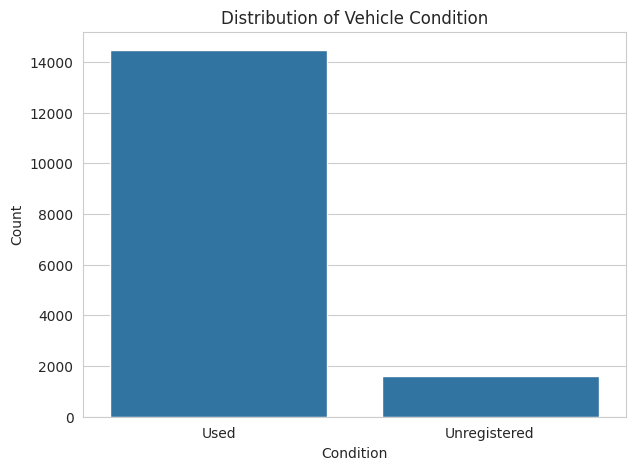

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(7, 5))
sns.countplot(data=merged_df, x='Condition', order=merged_df['Condition'].value_counts().index)
plt.title('Distribution of Vehicle Condition')
plt.xlabel('Condition')
plt.ylabel('Count')
plt.show()

In [ ]:
if 'Title' in merged_df.columns:
    merged_df = merged_df.drop(columns=['Title'])
    print("Column 'Title' successfully deleted.")
else:
    print("Column 'Title' not found in the DataFrame.")

print("\nUpdated DataFrame info after 'Title' column deletion:")
merged_df.info()

Column 'Title' successfully deleted.

Updated DataFrame info after 'Title' column deletion:
<class 'pandas.core.frame.DataFrame'>
Index: 16067 entries, 0 to 19864
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         16067 non-null  object 
 1   Make          16067 non-null  object 
 2   Model         16067 non-null  object 
 3   YOM           16067 non-null  float64
 4   Mileage (km)  16067 non-null  float64
 5   Gear          16067 non-null  object 
 6   Fuel Type     16067 non-null  object 
 7   Options       16067 non-null  object 
 8   Engine (cc)   16067 non-null  float64
 9   Details       16067 non-null  object 
 10  Vehicle Age   16067 non-null  float64
 11  Condition     16067 non-null  object 
dtypes: float64(4), object(8)
memory usage: 1.6+ MB


### Options

In [ ]:
print("\n--- Unique values in 'Options' (first 20) ---")
print(merged_df['Options'].unique()[:50])

print("\n--- Value counts of 'Options' (top 20) ---")
print(merged_df['Options'].value_counts().head(50))

print(f"\nNumber of unique values in 'Options': {merged_df['Options'].nunique()}")
print(f"Number of null values in 'Options': {merged_df['Options'].isnull().sum()}")


--- Unique values in 'Options' (first 20) ---
['AIR CONDITION, POWER STEERING, POWER MIRROR, POWER WINDOW'
 'AIR CONDITION, POWER STEERING'
 'AIR CONDITION, POWER STEERING, POWER WINDOW'
 'AIR CONDITION,POWER STEERING,POWER MIRROR,POWER WINDOW' 'AIR CONDITION'
 'AIR CONDITION, POWER MIRROR, POWER WINDOW' '-' 'POWER STEERING'
 'POWER MIRROR,POWER WINDOW' 'AIR CONDITION, POWER STEERING, POWER MIRROR'
 'POWER STEERING, POWER MIRROR, POWER WINDOW'
 'POWER STEERING, POWER WINDOW'
 'AIR CONDITION,POWER STEERING,POWER WINDOW'
 'AIR CONDITION,POWER STEERING,POWER MIRROR' 'AIR CONDITION, POWER MIRROR'
 'POWER MIRROR' 'AIR CONDITION,POWER STEERING'
 'AIR CONDITION, POWER WINDOW' 'POWER STEERING,POWER MIRROR'
 'POWER STEERING,POWER MIRROR,POWER WINDOW' 'AIR CONDITION,POWER WINDOW'
 'AIR CONDITION,POWER MIRROR,POWER WINDOW' 'POWER WINDOW'
 'POWER STEERING, POWER MIRROR'
 'AIR CONDITION, POWER STEERING, POWER MIRROR, POWER WINDOW '
 'AIR CONDITION,POWER STEERING,POWER MIRROR,POWER WINDOW    '
 'AI

In [ ]:
merged_df["Options"] = merged_df["Options"].astype(str).str.strip()
merged_df["Options"] = merged_df["Options"].replace("-", "")

In [ ]:
merged_df["Has_AC"] = merged_df["Options"].str.contains("AIR CONDITION", case=False).astype(int)
merged_df["Has_PowerSteering"] = merged_df["Options"].str.contains("POWER STEERING", case=False).astype(int)
merged_df["Has_PowerMirror"] = merged_df["Options"].str.contains("POWER MIRROR", case=False).astype(int)
merged_df["Has_PowerWindow"] = merged_df["Options"].str.contains("POWER WINDOW", case=False).astype(int)

In [ ]:
merged_df = merged_df.drop(columns=["Options"])

In [ ]:
merged_df["Option_Count"] = (
    merged_df["Has_AC"] +
    merged_df["Has_PowerSteering"] +
    merged_df["Has_PowerMirror"] +
    merged_df["Has_PowerWindow"]
)

The Options field was transformed into binary equipment indicators (e.g., air conditioning, power steering) rather than treated as a raw categorical string, improving interpretability and reducing noise from inconsistent formatting.

### Visializing Relationships

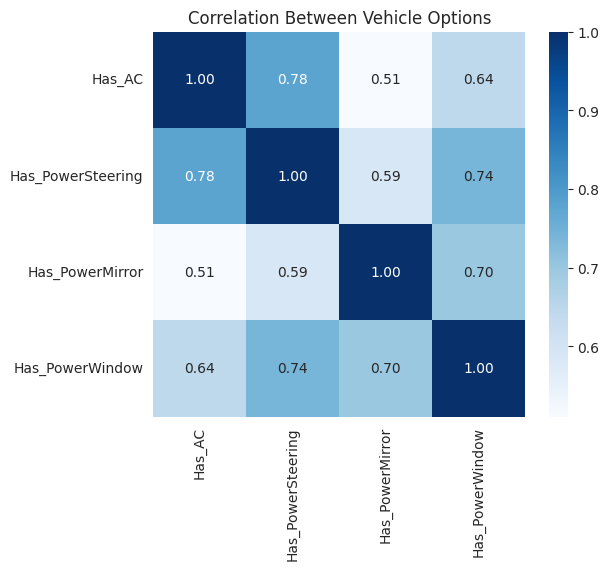

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

option_cols = ["Has_AC", "Has_PowerSteering", "Has_PowerMirror", "Has_PowerWindow"]

plt.figure(figsize=(6,5))
sns.heatmap(
    merged_df[option_cols].corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Between Vehicle Options")
plt.show()

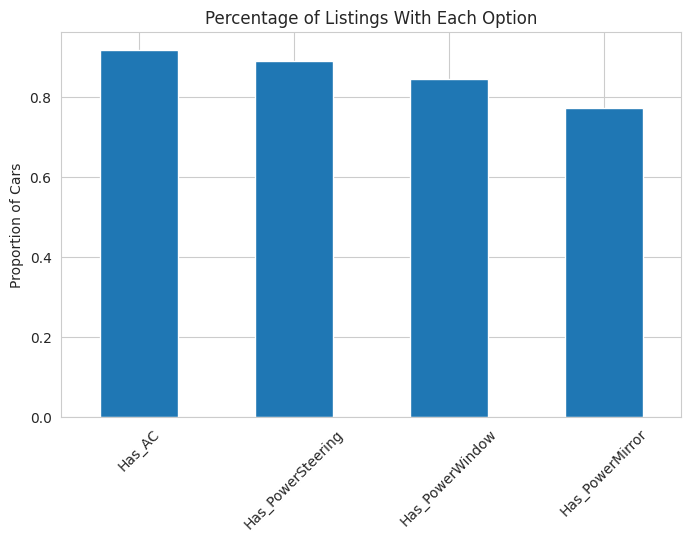

In [ ]:
option_means = merged_df[option_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
option_means.plot(kind="bar")

plt.title("Percentage of Listings With Each Option")
plt.ylabel("Proportion of Cars")
plt.xticks(rotation=45)
plt.show()

In [ ]:
merged_df.head()

,Price,Make,Model,YOM,Mileage (km),Gear,Fuel Type,Engine (cc),Details,Vehicle Age,Condition,Has_AC,Has_PowerSteering,Has_PowerMirror,Has_PowerWindow,Option_Count
0,"Rs. 15,500,000",Toyota,Premio G Superior,2018.0,136500.0,Automatic,Petrol,1500.0,"First owner, personally used vehicle, Company ...",8.0,Used,1,1,1,1,4
1,"Rs. 3,950,000(Ongoing Lease)",Chevrolet,Beat LT,2012.0,107000.0,Manual,Petrol,1200.0,කරුණාකර හොදින් කියවා WhatsApp පණිවුඩ මගින් විස...,14.0,Used,1,1,1,1,4
2,"Rs. 7,390,000",Mitsubishi,EK Wagon G PILOT,2023.0,15000.0,Automatic,Petrol,660.0,MITSUBISHI EK Wagon G GradePush Start/ AUTO Pi...,3.0,Unregistered,1,1,1,1,4
3,Negotiable,Suzuki,Swift RS Turbo,2017.0,106500.0,Automatic,Petrol,1000.0,1st owner100% accident freeExcellent body cond...,9.0,Used,1,1,1,1,4
4,"Rs. 3,290,000",Toyota,Soluna,2000.0,149003.0,Manual,Petrol,1500.0,🔶️Toyota Soluna🔶️2000 Brandnew🔶️1500cc 5fwd🔶️A...,26.0,Used,1,1,0,0,2


### Price

Inspect the 'Price' column for null values, unique non-numeric entries, and their counts to understand its data quality.

In [ ]:
import numpy as np

# Count null values in 'Price'
null_count_price = merged_df['Price'].isnull().sum()
print(f"\n--- Null values in 'Price': {null_count_price} ---")

# Identify unique non-numeric values in 'Price'
# Convert to string first to use string methods reliably
price_str = merged_df['Price'].astype(str)

# Define a regex pattern to find values that are not purely numeric (allowing for one decimal point)
# This pattern looks for anything that is NOT a digit or a period, OR if the string starts/ends with a period,
# OR if it contains multiple periods. This is a robust way to identify non-numeric-like strings.
# A simpler approach is to use pd.to_numeric with errors='coerce' and then check for NaNs.


# Identify non-numeric entries by attempting conversion to numeric and checking for NaNs
non_numeric_price_mask = pd.to_numeric(price_str.str.replace('Rs.', '', regex=False).str.replace(',', '', regex=False).str.strip(), errors='coerce').isna()

# Filter for original non-numeric values that are not actual NaNs from the original column
non_numeric_entries = merged_df.loc[non_numeric_price_mask & ~merged_df['Price'].isna(), 'Price']

unique_non_numeric_values = non_numeric_entries.unique()

print("\n--- Unique non-numeric entries in 'Price' ---")
if len(unique_non_numeric_values) > 0:
    # Displaying top 50 unique non-numeric values if there are many
    print(unique_non_numeric_values[:50])
    print("\n--- Value counts of unique non-numeric entries (top 20) ---")
    print(non_numeric_entries.value_counts().head(20))
else:
    print("No apparent non-numeric values found besides potential NaNs.")

# Also show total entries and how many are numeric vs non-numeric after a more thorough check
clean_price_for_check = price_str.str.replace('Rs.', '', regex=False).str.replace(',', '', regex=False).str.strip()
numeric_check = pd.to_numeric(clean_price_for_check, errors='coerce')

print(f"\n--- Total entries: {len(merged_df)} ---")
print(f"--- Numeric-like entries (after cleaning symbols): {numeric_check.count()} ---")
print(f"--- Non-numeric/NaN entries (after cleaning symbols): {len(merged_df) - numeric_check.count()} ---")


--- Null values in 'Price': 0 ---

--- Unique non-numeric entries in 'Price' ---
['Rs. 3,950,000(Ongoing Lease)' 'Negotiable'
 'Rs. 3,650,000(Ongoing Lease)' 'Rs. 4,650,000(Ongoing Lease)'
 'Negotiable(Ongoing Lease)' 'Rs. 4,130,000(Ongoing Lease)'
 'Rs. 3,400,000(Ongoing Lease)' 'Rs. 5,100,000(Ongoing Lease)'
 'Rs. 3,525,000(Ongoing Lease)' 'Rs. 4,100,000(Ongoing Lease)'
 'Rs. 6,850,000(Ongoing Lease)' 'Rs. 750,000(Ongoing Lease)'
 'Rs. 7,300,000(Ongoing Lease)' 'Rs. 11,000,000(Ongoing Lease)'
 'Rs. 52,090,000(Ongoing Lease)' 'Rs. 11,340,000(Ongoing Lease)'
 'Rs. 2,950,000(Ongoing Lease)' 'Rs. 1,250,000(Ongoing Lease)'
 'Rs. 5,600,000(Ongoing Lease)' 'Rs. 3,000,000(Ongoing Lease)'
 'Rs. 1,690,000(Ongoing Lease)' 'Rs. 775,000(Ongoing Lease)'
 'Rs. 1,475,000(Ongoing Lease)' 'Rs. 6,000,000(Ongoing Lease)'
 'Rs. 1,850,000(Ongoing Lease)' 'Rs. 1,975,000(Ongoing Lease)'
 'Rs. 9,250,000(Ongoing Lease)' 'Rs. 8,490,000(Ongoing Lease)'
 'Rs. 5,800,000(Ongoing Lease)' 'Rs. 3,500,000(Ongoing Lea

In [ ]:
merged_df = merged_df[~merged_df["Price"].str.contains("Negotiable", case=False)]

In [ ]:
merged_df["Price"] = (
    merged_df["Price"]
    .str.replace("Rs.", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace(r"\(Ongoing Lease\)", "", regex=True)
    .str.strip()
)

merged_df["Price"] = pd.to_numeric(merged_df["Price"], errors="coerce")

/tmp/ipython-input-2241986140.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df["Price"] = (
/tmp/ipython-input-2241986140.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df["Price"] = pd.to_numeric(merged_df["Price"], errors="coerce")


In [ ]:
merged_df = merged_df.dropna(subset=["Price"])

In [ ]:
print("Rows remaining:", merged_df.shape)

Rows remaining: (13125, 16)


In [ ]:
merged_df.head()

,Price,Make,Model,YOM,Mileage (km),Gear,Fuel Type,Engine (cc),Details,Vehicle Age,Condition,Has_AC,Has_PowerSteering,Has_PowerMirror,Has_PowerWindow,Option_Count
0,15500000,Toyota,Premio G Superior,2018.0,136500.0,Automatic,Petrol,1500.0,"First owner, personally used vehicle, Company ...",8.0,Used,1,1,1,1,4
1,3950000,Chevrolet,Beat LT,2012.0,107000.0,Manual,Petrol,1200.0,කරුණාකර හොදින් කියවා WhatsApp පණිවුඩ මගින් විස...,14.0,Used,1,1,1,1,4
2,7390000,Mitsubishi,EK Wagon G PILOT,2023.0,15000.0,Automatic,Petrol,660.0,MITSUBISHI EK Wagon G GradePush Start/ AUTO Pi...,3.0,Unregistered,1,1,1,1,4
4,3290000,Toyota,Soluna,2000.0,149003.0,Manual,Petrol,1500.0,🔶️Toyota Soluna🔶️2000 Brandnew🔶️1500cc 5fwd🔶️A...,26.0,Used,1,1,0,0,2
6,3675000,Suzuki,Alto Japan,2003.0,110000.0,Automatic,Petrol,660.0,Suzuki Japan Alto 2003-2006 (Automatic) - Exce...,23.0,Used,1,1,0,1,3


Listings marked as ‘Negotiable’ or ‘Ongoing Lease’ were excluded from baseline training, as they do not represent a consistent numeric resale price target. Removing these entries are expected to improve regression reliability and reduce target noise.

### Visualize 'Price' Distribution


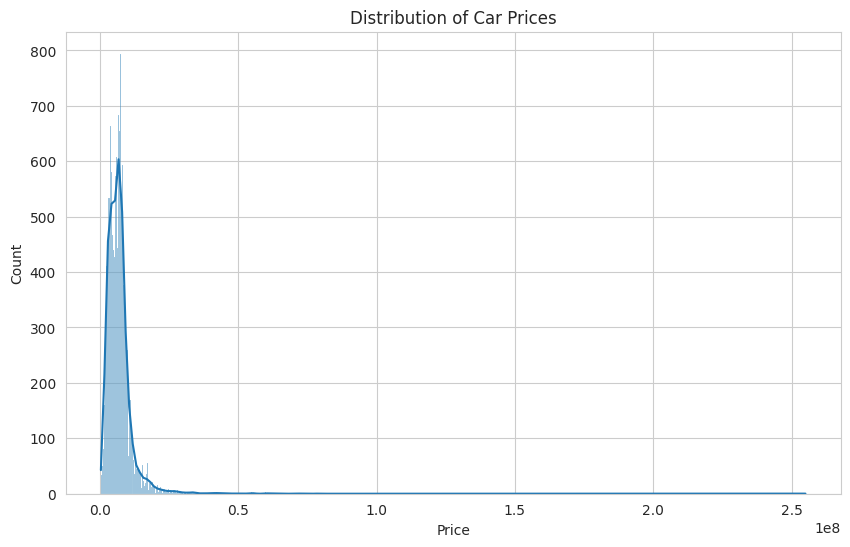

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(data=merged_df, x='Price', kde=True)
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

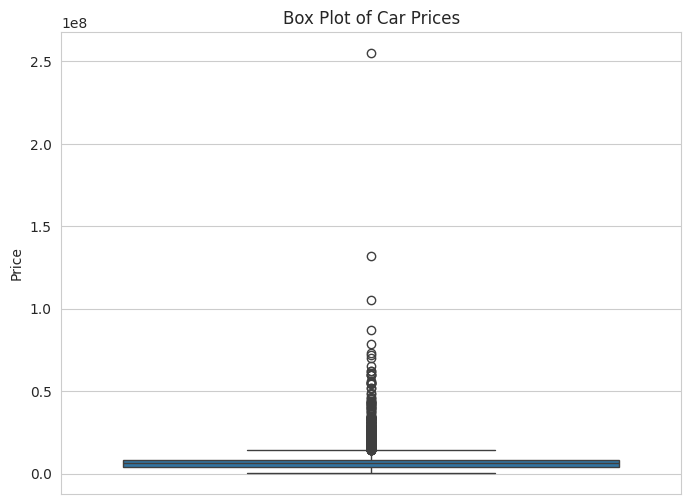

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))
sns.boxplot(y=merged_df['Price'])

plt.title('Box Plot of Car Prices')
plt.ylabel('Price')

plt.show()

The 'Price' column underwent cleaning, which involved removing 'Negotiable' and 'Ongoing Lease' entries and converting the values to a numeric type.

Histogram reveals a heavily right-skewed distribution for 'Price', with a prominent peak at the lower price range, indicating that more affordable vehicles constitute the majority of listings.

The box plot identifies that a significant number of outliers on the higher end of the price spectrum, confirming the presence of exceptionally expensive vehicles compared to the bulk of the data.

`Given the highly skewed nature of the 'Price' distribution, data transformation (e.g., logarithmic transformation) should be considered for future modeling efforts to mitigate the impact of extreme values and potentially achieve a more normal distribution.`

`Further investigation into the high-priced outliers is warranted to determine if they represent niche markets, luxury vehicles, or potential data entry errors, which could influence subsequent analytical decisions.`


### Inspecting high value vahicles

In [ ]:
high_value_cars = merged_df[merged_df['Price'] > 100000000]

print(f"\nNumber of cars valued more than 1,000,000: {len(high_value_cars)}")


Number of cars valued more than 1,000,000: 3


In [ ]:
print("\nFirst 5 rows of cars valued more than 1,000,000:")
high_value_cars.head()


First 5 rows of cars valued more than 1,000,000:


,Price,Make,Model,YOM,Mileage (km),Gear,Fuel Type,Engine (cc),Details,Vehicle Age,Condition,Has_AC,Has_PowerSteering,Has_PowerMirror,Has_PowerWindow,Option_Count
8043,132000000,Honda,Fit Shuttle Gp7,2017.0,87000.0,Automatic,Hybrid,1500.0,🚘 Honda GP7 – 2017 (Reg 2017)🎨 Pearl White📍 Mi...,9.0,Used,1,1,1,1,4
15753,105000000,Suzuki,Spacia Turbo,2025.0,380.0,Automatic,Hybrid,660.0,Fully options custom z spacia turbo. 2025 bran...,1.0,Used,1,1,1,0,3
15837,255000000,Mercedes-Benz,CLA 200 Premium Plus,2019.0,1.0,Automatic,Petrol,1500.0,Mercedes-Benz CLA 200 Premium Plus – 2019 (CBI...,7.0,Used,1,1,1,1,4


In [ ]:
duplicate_rows = merged_df[merged_df.duplicated()]

print(f"\n--- Number of duplicate rows found: {len(duplicate_rows)} ---")

if not duplicate_rows.empty:
    print("\n--- First 5 duplicate rows (if any): ---")
    print(duplicate_rows.head())
else:
    print("No duplicate rows found in the DataFrame.")


--- Number of duplicate rows found: 1684 ---

--- First 5 duplicate rows (if any): ---
       Price      Make                     Model     YOM  Mileage (km)  \
178  8000000     Honda           Fit GP5 S Grade  2015.0        1234.0   
264  6750000    Suzuki  Wagon R FX Safety Import  2024.0        5000.0   
265  8250000  Daihatsu                     Tanto  2024.0         340.0   
308  5750000    Suzuki  Wagon R Stingray J Style  2015.0      112000.0   
310  7800000     Honda                     N Box  2025.0        4000.0   

          Gear Fuel Type  Engine (cc)  \
178  Automatic    Hybrid       1500.0   
264  Automatic    Petrol        658.0   
265  Automatic    Petrol        660.0   
308  Automatic    Petrol        650.0   
310  Automatic    Petrol        660.0   

                                               Details  Vehicle Age  \
178  Honda FIT GP5 S Grade 2015Fully loaded highest...         11.0   
264  🚗This is to import a Suzuki Wagon R FX Safety ...          2.0   
265  Da

## Remove Duplicate Rows

Remove duplicate rows from the DataFrame, keeping only the first occurrence. In-case the merge process introduced any duplicate entries.

In [ ]:
initial_row_count = len(merged_df)
merged_df.drop_duplicates(inplace=True)

print(f"Removed {initial_row_count - len(merged_df)} duplicate rows.")
print(f"\nNumber of rows after removing duplicates: {len(merged_df)}")

# Re-check for duplicates to confirm
duplicate_rows_after_removal = merged_df[merged_df.duplicated()]
print(f"\nNumber of duplicate rows found after removal: {len(duplicate_rows_after_removal)}")

print("\nUpdated DataFrame head after duplicate removal:")
merged_df.head()

Removed 1684 duplicate rows.

Number of rows after removing duplicates: 11441

Number of duplicate rows found after removal: 0

Updated DataFrame head after duplicate removal:


,Price,Make,Model,YOM,Mileage (km),Gear,Fuel Type,Engine (cc),Details,Vehicle Age,Condition,Has_AC,Has_PowerSteering,Has_PowerMirror,Has_PowerWindow,Option_Count
0,15500000,Toyota,Premio G Superior,2018.0,136500.0,Automatic,Petrol,1500.0,"First owner, personally used vehicle, Company ...",8.0,Used,1,1,1,1,4
1,3950000,Chevrolet,Beat LT,2012.0,107000.0,Manual,Petrol,1200.0,කරුණාකර හොදින් කියවා WhatsApp පණිවුඩ මගින් විස...,14.0,Used,1,1,1,1,4
2,7390000,Mitsubishi,EK Wagon G PILOT,2023.0,15000.0,Automatic,Petrol,660.0,MITSUBISHI EK Wagon G GradePush Start/ AUTO Pi...,3.0,Unregistered,1,1,1,1,4
4,3290000,Toyota,Soluna,2000.0,149003.0,Manual,Petrol,1500.0,🔶️Toyota Soluna🔶️2000 Brandnew🔶️1500cc 5fwd🔶️A...,26.0,Used,1,1,0,0,2
6,3675000,Suzuki,Alto Japan,2003.0,110000.0,Automatic,Petrol,660.0,Suzuki Japan Alto 2003-2006 (Automatic) - Exce...,23.0,Used,1,1,0,1,3


### Details

Removing Details column

In [ ]:
if 'Details' in merged_df.columns:
    merged_df = merged_df.drop(columns=['Details'])
    print("Column 'Details' successfully deleted.")
else:
    print("Column 'Details' not found in the DataFrame.")

print("\nUpdated DataFrame info after 'Details' column deletion:")
merged_df.info()

Column 'Details' successfully deleted.

Updated DataFrame info after 'Details' column deletion:
<class 'pandas.core.frame.DataFrame'>
Index: 11441 entries, 0 to 19864
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Price              11441 non-null  int64  
 1   Make               11441 non-null  object 
 2   Model              11441 non-null  object 
 3   YOM                11441 non-null  float64
 4   Mileage (km)       11441 non-null  float64
 5   Gear               11441 non-null  object 
 6   Fuel Type          11441 non-null  object 
 7   Engine (cc)        11441 non-null  float64
 8   Vehicle Age        11441 non-null  float64
 9   Condition          11441 non-null  object 
 10  Has_AC             11441 non-null  int64  
 11  Has_PowerSteering  11441 non-null  int64  
 12  Has_PowerMirror    11441 non-null  int64  
 13  Has_PowerWindow    11441 non-null  int64  
 14  Option_Count       11441 no

In [ ]:
merged_df.shape

(11441, 15)

### Ctd. on 'Price'

In [ ]:
merged_df.sort_values("Price", ascending=False).head(10)

,Price,Make,Model,YOM,Mileage (km),Gear,Fuel Type,Engine (cc),Vehicle Age,Condition,Has_AC,Has_PowerSteering,Has_PowerMirror,Has_PowerWindow,Option_Count
15837,255000000,Mercedes-Benz,CLA 200 Premium Plus,2019.0,1.0,Automatic,Petrol,1500.0,7.0,Used,1,1,1,1,4
8043,132000000,Honda,Fit Shuttle Gp7,2017.0,87000.0,Automatic,Hybrid,1500.0,9.0,Used,1,1,1,1,4
15753,105000000,Suzuki,Spacia Turbo,2025.0,380.0,Automatic,Hybrid,660.0,1.0,Used,1,1,1,0,3
7687,86900000,Toyota,ROOMY,2023.0,15000.0,Automatic,Petrol,1000.0,3.0,Unregistered,1,1,1,1,4
3681,78500000,Land-Rover,Defender P400e HSE,2025.0,47.0,Automatic,Petrol,2000.0,1.0,Unregistered,1,1,1,1,4
4881,72950000,Suzuki,Spacia Custom Xs Safety,2018.0,48000.0,Automatic,Hybrid,650.0,8.0,Used,1,1,1,1,4
16928,72000000,Toyota,Yaris,2011.0,125000.0,Automatic,Petrol,1300.0,15.0,Used,1,1,1,1,4
11970,70000000,Mercedes-Benz,S300 LONG WHEEL,2017.0,49800.0,Automatic,Hybrid,2140.0,9.0,Used,1,1,1,1,4
7406,65000000,Mercedes-Benz,LONG WHEEL HYBRID,2017.0,49800.0,Automatic,Other,2140.0,9.0,Used,1,1,1,1,4
16988,62000000,Nissan,Tiida Latio,2007.0,160000.0,Automatic,Petrol,1500.0,19.0,Used,1,1,1,1,4


In [ ]:
# Calculate the 99th percentile of the 'Price' column
price_99th_percentile = merged_df['Price'].quantile(0.99)

# Count vehicles in the top 1% of prices
top_1_percent_cars = merged_df[merged_df['Price'] >= price_99th_percentile]
print(f"\nNumber of cars in the top 1% of prices (above {price_99th_percentile:,.0f}): {len(top_1_percent_cars)}")

# Count vehicles priced above 50,000,000
cars_above_50_million = merged_df[merged_df['Price'] > 50000000]
print(f"Number of cars priced above 50,000,000: {len(cars_above_50_million)}")


Number of cars in the top 1% of prices (above 26,500,000): 118
Number of cars priced above 50,000,000: 23


In [ ]:
print("\n--- Sample of cars in the top 1% of prices ---")
if not top_1_percent_cars.empty:
    print(top_1_percent_cars.head())
else:
    print("No cars found in the top 1% of prices.")

print("\n--- Sample of cars priced above 50,000,000 ---")
if not cars_above_50_million.empty:
    print(cars_above_50_million.head())
else:
    print("No cars found priced above 50,000,000.")


--- Sample of cars in the top 1% of prices ---
        Price           Make              Model     YOM  Mileage (km)  \
13   41500000            BMW              740le  2017.0       47000.0   
29   30500000  Mercedes-Benz  C200 Premium Plus  2020.0       62000.0   
416  40000000     Land-Rover       Defender 110  2013.0      102913.0   
482  44000000     Land-Rover       Defender 110  2014.0       72941.0   
626  46000000            BMW              740LE  2017.0       60000.0   

          Gear Fuel Type  Engine (cc)  Vehicle Age Condition  Has_AC  \
13   Automatic    Petrol       2000.0          9.0      Used       1   
29   Automatic    Petrol       1500.0          6.0      Used       1   
416     Manual    Diesel       2200.0         13.0      Used       0   
482     Manual    Diesel       2200.0         12.0      Used       0   
626  Automatic    Petrol       2000.0          9.0      Used       1   

     Has_PowerSteering  Has_PowerMirror  Has_PowerWindow  Option_Count  
13     

### Saving

In [ ]:
output_file_path = 'cleaned-before_log.csv'
merged_df.to_csv(output_file_path, index=False)

print(f"Cleaned DataFrame successfully saved to {output_file_path}")

Cleaned DataFrame successfully saved to cleaned-before_log.csv


### Log transform price

In [ ]:
import numpy as np

merged_df["Log_Price"] = np.log1p(merged_df["Price"])

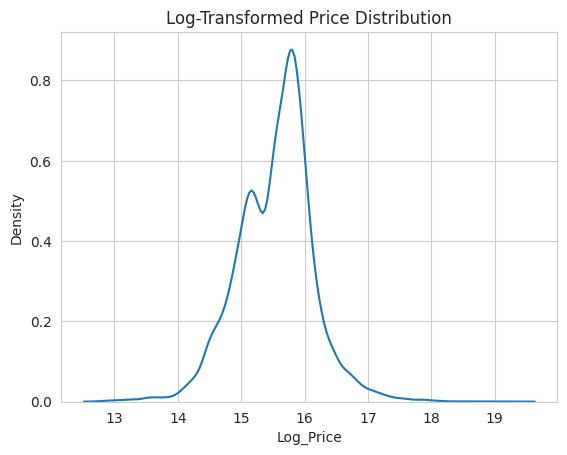

In [ ]:
sns.kdeplot(merged_df["Log_Price"])
plt.title("Log-Transformed Price Distribution")
plt.show()

In [ ]:
merged_df.sort_values("Price", ascending=False).head(15)

,Price,Make,Model,YOM,Mileage (km),Gear,Fuel Type,Engine (cc),Vehicle Age,Condition,Has_AC,Has_PowerSteering,Has_PowerMirror,Has_PowerWindow,Option_Count,Log_Price
15837,255000000,Mercedes-Benz,CLA 200 Premium Plus,2019.0,1.0,Automatic,Petrol,1500.0,7.0,Used,1,1,1,1,4,19.356774
8043,132000000,Honda,Fit Shuttle Gp7,2017.0,87000.0,Automatic,Hybrid,1500.0,9.0,Used,1,1,1,1,4,18.698312
15753,105000000,Suzuki,Spacia Turbo,2025.0,380.0,Automatic,Hybrid,660.0,1.0,Used,1,1,1,0,3,18.469471
7687,86900000,Toyota,ROOMY,2023.0,15000.0,Automatic,Petrol,1000.0,3.0,Unregistered,1,1,1,1,4,18.280269
3681,78500000,Land-Rover,Defender P400e HSE,2025.0,47.0,Automatic,Petrol,2000.0,1.0,Unregistered,1,1,1,1,4,18.178609
4881,72950000,Suzuki,Spacia Custom Xs Safety,2018.0,48000.0,Automatic,Hybrid,650.0,8.0,Used,1,1,1,1,4,18.105285
16928,72000000,Toyota,Yaris,2011.0,125000.0,Automatic,Petrol,1300.0,15.0,Used,1,1,1,1,4,18.092177
11970,70000000,Mercedes-Benz,S300 LONG WHEEL,2017.0,49800.0,Automatic,Hybrid,2140.0,9.0,Used,1,1,1,1,4,18.064006
7406,65000000,Mercedes-Benz,LONG WHEEL HYBRID,2017.0,49800.0,Automatic,Other,2140.0,9.0,Used,1,1,1,1,4,17.989898
16988,62000000,Nissan,Tiida Latio,2007.0,160000.0,Automatic,Petrol,1500.0,19.0,Used,1,1,1,1,4,17.942645


In [ ]:
upper = merged_df["Price"].quantile(0.99)
merged_df = merged_df[merged_df["Price"] <= upper]

Vehicle prices exhibit a strongly right-skewed distribution with a small number of high-value luxury listings. To reduce the influence of extreme outliers, the top 1% of prices were removed and log-transformation was applied for regression modelling.

In [ ]:
merged_df.head()

,Price,Make,Model,YOM,Mileage (km),Gear,Fuel Type,Engine (cc),Vehicle Age,Condition,Has_AC,Has_PowerSteering,Has_PowerMirror,Has_PowerWindow,Option_Count,Log_Price
0,15500000,Toyota,Premio G Superior,2018.0,136500.0,Automatic,Petrol,1500.0,8.0,Used,1,1,1,1,4,16.556351
1,3950000,Chevrolet,Beat LT,2012.0,107000.0,Manual,Petrol,1200.0,14.0,Used,1,1,1,1,4,15.189226
2,7390000,Mitsubishi,EK Wagon G PILOT,2023.0,15000.0,Automatic,Petrol,660.0,3.0,Unregistered,1,1,1,1,4,15.815638
4,3290000,Toyota,Soluna,2000.0,149003.0,Manual,Petrol,1500.0,26.0,Used,1,1,0,0,2,15.006398
6,3675000,Suzuki,Alto Japan,2003.0,110000.0,Automatic,Petrol,660.0,23.0,Used,1,1,0,1,3,15.117064


### Correlation Analysis

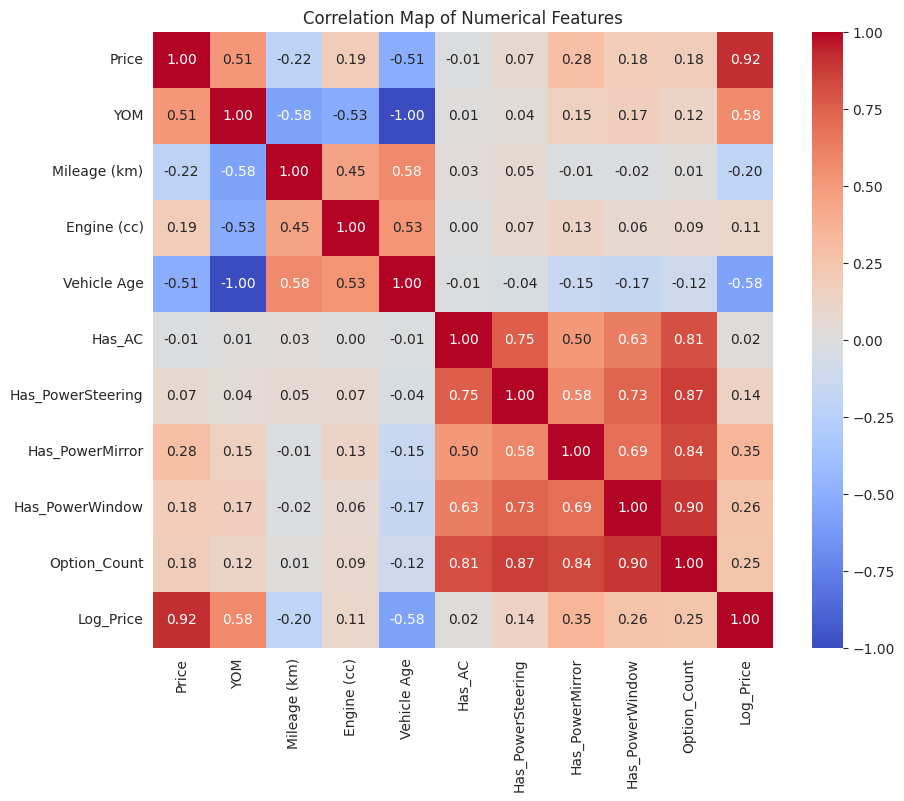

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Select only numerical columns for correlation matrix
numerical_df = merged_df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Map of Numerical Features')
plt.show()

### Visualize Factors Affecting Price - Numerical Features

Identify and visualize the numerical features most correlated with 'Log_Price' using scatter plots.


--- Top Numerical Features Correlated with Log_Price ---
Price              0.915958
YOM                0.577846
Has_PowerMirror    0.349783
Has_PowerWindow    0.262394
Option_Count       0.247976
Name: Log_Price, dtype: float64


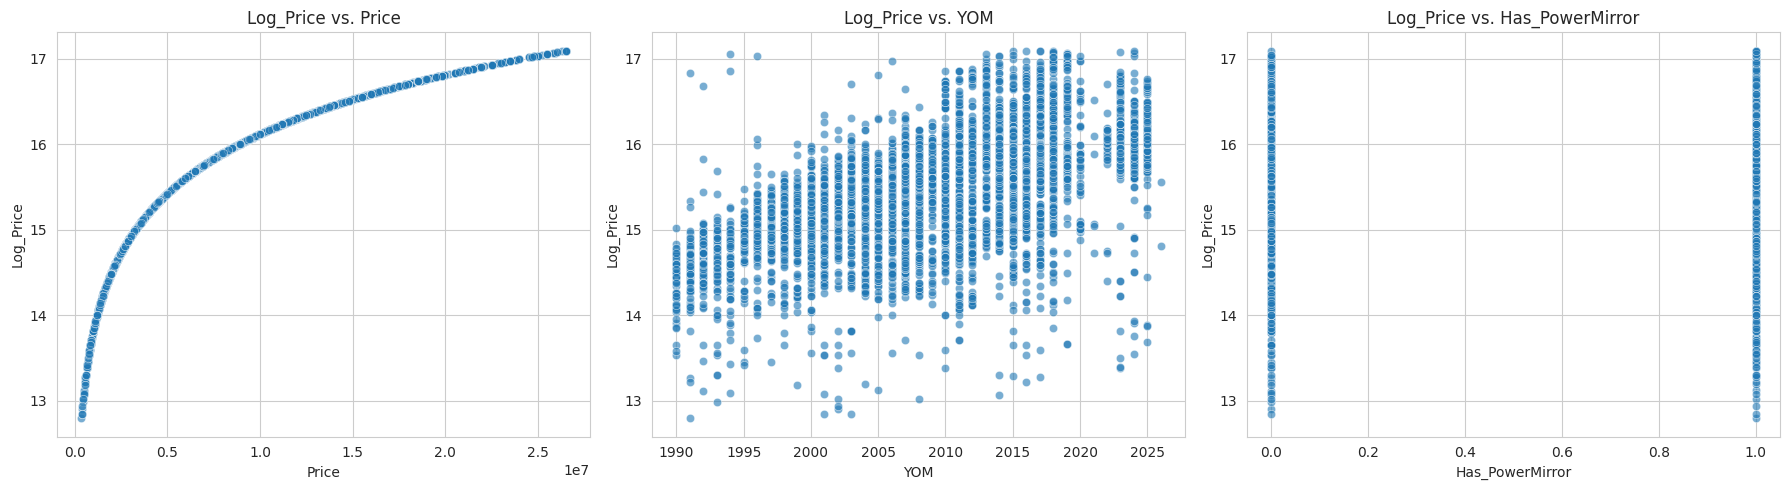

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Get correlations with Log_Price
correlations = merged_df.corr(numeric_only=True)['Log_Price'].sort_values(ascending=False)

# Exclude Log_Price itself from the list of features to plot
top_correlated_features = correlations.drop('Log_Price').index.tolist()

print("\n--- Top Numerical Features Correlated with Log_Price ---")
print(correlations.drop('Log_Price').head(5))

# Create scatter plots for the top 3 (or fewer if less available) correlated numerical features
num_plots = min(len(top_correlated_features), 3)
fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 5))

if num_plots == 1:
    axes = [axes]

for i, feature in enumerate(top_correlated_features[:num_plots]):
    sns.scatterplot(data=merged_df, x=feature, y='Log_Price', ax=axes[i], alpha=0.6)
    axes[i].set_title(f'Log_Price vs. {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Log_Price')

plt.tight_layout()
plt.show()

### Visualize Factors Affecting Price - Categorical Features

Visualize the relationship between key categorical features ('Make', 'Fuel Type', 'Gear', 'Condition') and 'Log_Price' using box plots.

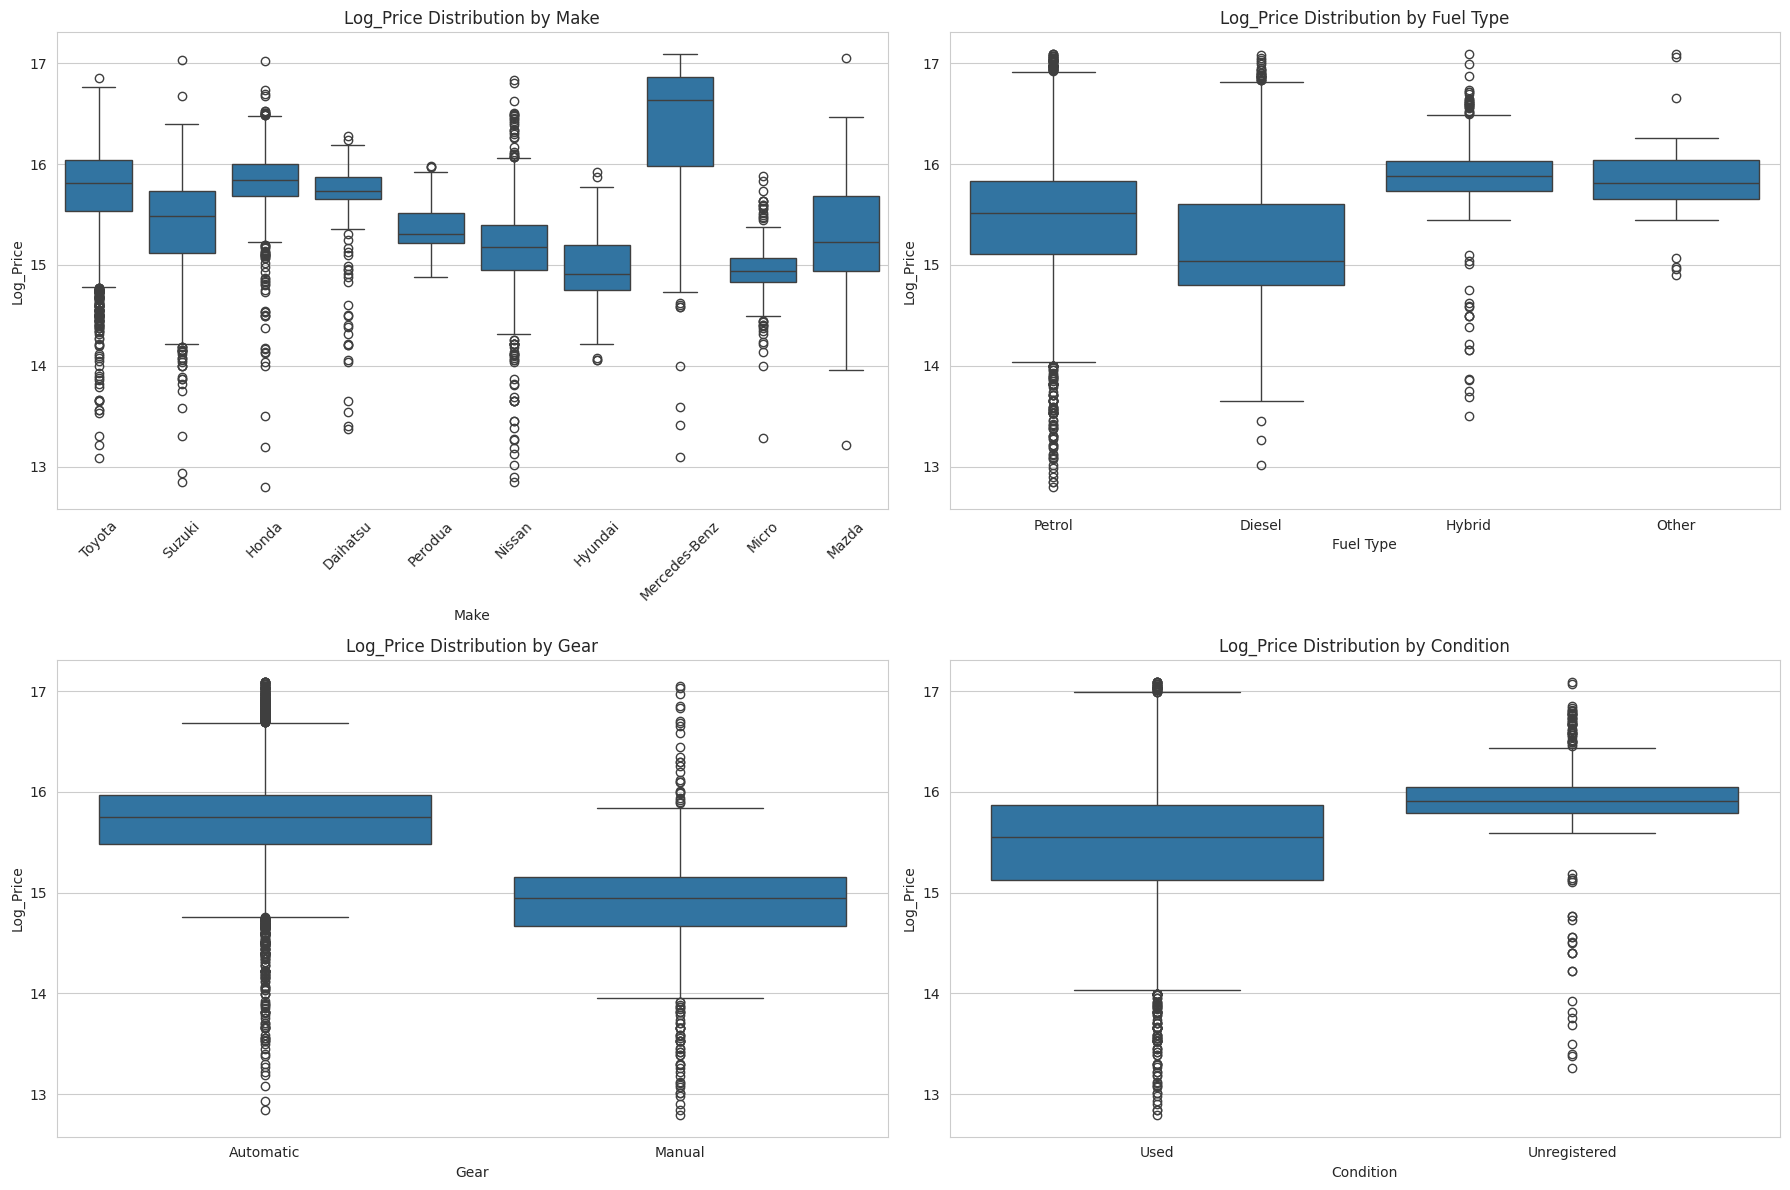

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

categorical_features = ['Make', 'Fuel Type', 'Gear', 'Condition']

# Create box plots for selected categorical features vs. Log_Price
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    if feature == 'Make':
        # For 'Make', plot only the top N makes for readability
        top_makes = merged_df['Make'].value_counts().nlargest(10).index
        sns.boxplot(data=merged_df[merged_df['Make'].isin(top_makes)], x=feature, y='Log_Price', ax=axes[i])
        axes[i].tick_params(axis='x', rotation=45)
    else:
        sns.boxplot(data=merged_df, x=feature, y='Log_Price', ax=axes[i])

    axes[i].set_title(f'Log_Price Distribution by {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Log_Price')

plt.tight_layout()
plt.show()